# mol_fMRI_v5.5 – molecular fMRI preprocessing and signal change maps

Interactive pipeline for Bruker functional (EPI) data: raw scan → NIfTI → (distortion correction) → motion correction → spatial smoothing → percent signal change (PSC) maps and ROI time courses.

**How to use**
1. Run the function-library cell and the step-selection cell (tick the steps to run).
2. Choose the raw data folder, enter functional/structural scan numbers and the baseline/signal window size, and run the following cells top to bottom.
3. Hand-drawn masks (in the functional analysis folder) are requested when missing: `mask_mean_mc_func.nii.gz` (brain, drawn on `middle_vol.nii.gz`) and `mask_mean_mc_func_cannulas.nii.gz`.
4. Select baseline and signal start volumes, then draw ROIs named `roi_{protein/aav}_{direct|aav}_{analyte}_{left|right}.nii.gz` for the time-course analysis.

**Changes in v5.5 compared to v5.4**
- Motion correction: two passes (cubic, then heptic against the mean of pass 1), brain-weighted, no more `-linear`.
- Spatial smoothing is done inside the brain mask (normalized convolution) before the signal change maps are computed.
- The exclusion mask (`mask_thresholded.nii.gz`) replaces the 15–80 percentile cut. A voxel is kept only if it is at least 3 voxels from the brain edge, has a baseline of at least 50% of the median, and a baseline tSNR (`tsnr_baseline_*.nii.gz`) of at least 60% of the median. The mask is moved to structural space with the coregistration affine (`struct_mask_from_functional.nii.gz`) and intersected with the structural brain (`struct_mask_final.nii.gz`), which removes the isolated dead voxels inside clusters and the voxels outside the structural brain.
- A coregistration quality check (`coregistration_qc`) compares the registration with a header-only alignment, warns about implausible transforms, and writes `coregistration_qc.png` (overlay) and `coregistration_qc.txt`. It only reports; it does not change the transform.
- Coregistration may scale the functional image along the phase-encoding axis (within 0.92–1.08, rotations ≤ 5°, shifts ≤ 2 mm) to compensate EPI stretching. The axis comes from the "Phase-encoding axis" dropdown or is detected from brkraw's BIDS sidecar (cached in `func.detected_pe.json`); the scaling is switched off when distortion correction is used or the axis is unknown.

**Main outputs** (functional analysis folder): `func.nii.gz`, `mc_func.nii.gz`, `motion.1D`, `mc_reference_mean.nii.gz`, `sm_mc_func.nii.gz`, `scm_from_sm_*.nii.gz` (PSC map), `scm_timeseries_from_sm_*.nii.gz`, masked/cleaned PSC maps, ROI time courses and PSC plots.

Skipping a step (unticked checkbox) reuses existing files where the cell checks for them; delete e.g. `mc_func.nii.gz` to force a re-run.

In [79]:
# Molecular fMRI pipeline (mol_fMRI_v5.5) function library
# =====================================================================================================
# Function library of the molecular fMRI pipeline (mol_fMRI_v5.5)
#
# This cell only DEFINES functions and has no output; run it first. Functions that call external
# tools need them on the PATH: brkraw, FSL (fslmaths, fslstats, fslmerge, fslroi, fslhd) and AFNI
# (3dvolreg, 3dTstat, 3dresample). Most functions read/write files in the CURRENT WORKING DIRECTORY
# (the notebook changes into the analysis folder with os.chdir), so relative file names are used.
#
# Groups:
#   Conversion          bruker_to_nifti, extract_middle_volume
#   Preprocessing       motion_correction, plot_motion_parameters, masked_spatial_smoothing,
#                       spatial_smoothing, compute_mean_range, masking_file,
#                       shrink_mask_xz_linewise, create_intensity_mask,
#                       compute_tsnr, create_exclusion_mask, transform_mask_to_structural,
#                       restrict_to_structural_brain, coregistration_qc, get_phase_encoding_axis
#   Signal change       signal_change_map, roi_analysis
#   Scan metadata       func_param_extract, extract_subject_id
#   Notebook helpers    print_header, print_statement, bcolors, view_images, int_widget,
#                       print_selected_pipeline_steps, is_step_enabled, run_cmd
# =====================================================================================================

import pandas as pd
import numpy as np
from nipype.interfaces import afni, fsl
import nibabel as nib
import matplotlib.pyplot as plt
import os, datetime
import shutil
import glob
import subprocess
from pathlib import Path
import re
import getpass
import ipywidgets as widgets
from IPython.display import display
from ipyfilechooser import FileChooser
from tabulate import tabulate
import mol_fMRI_distortion_correction_rp as distortion_correction

# ---- Pipeline functions: each one is used by a pipeline step (selected via the checkboxes) ----

def bruker_to_nifti(in_path, scan_number, out_file):
    """Convert one Bruker scan to an LPI-oriented NIfTI file.

    Runs `brkraw tonii` in the current working directory, so call it after `os.chdir` into the
    output folder. Multi-echo scans (PVM_NEchoImages > 1) are merged along time with `fslmerge`.
    The result is reoriented to LPI with AFNI `3dresample`.

    Parameters
    ----------
    in_path : str or Path
        Folder containing the Bruker scan folders (the raw data folder of one subject/session).
    scan_number : str or int
        Bruker scan (experiment) number to convert.
    out_file : str
        Output NIfTI filename, e.g. "func.nii.gz".

    Side effects
    ------------
    Writes `G1_cp.nii.gz` (unoriented copy), `out_file` and `NIFTI_file_header_info.txt`
    (`fslhd` output) into the working directory."""

    scan_dir = os.path.join(in_path, scan_number)
    method_file = os.path.join(scan_dir, "method")

    # -------------------------------------------------------
    # Helper: safely collect only produced NIfTI files
    # -------------------------------------------------------
    def get_nifti_files(scan_number):
        return [
            f for f in glob.glob(f"*{scan_number}*.nii*")
            if os.path.isfile(f)
        ]

    # ---------- 1) Run brkraw tonii ----------
    cmd = ["brkraw", "tonii", f"{in_path}/", "-s", str(scan_number)]
    subprocess.run(cmd, check=True)

    # ---------- 2) Detect echo count ----------
    NoOfEchoImages = None
    if os.path.exists(method_file):
        with open(method_file) as f:
            for line in f:
                if "PVM_NEchoImages=" in line:
                    echo_str = line.split("=")[1].strip()
                    try:
                        NoOfEchoImages = int(echo_str)
                    except:
                        NoOfEchoImages = 1
                    break

    # ---------- 3) Collect produced NIfTI files ----------
    src_files = get_nifti_files(scan_number)

    if not src_files:
        raise RuntimeError(
            f"No NIfTI files found after brkraw conversion for scan {scan_number}"
        )

    # ---------- 4) Single echo OR unknown echo ----------
    if NoOfEchoImages is None or NoOfEchoImages == 1:
        # Just copy first detected nifti
        shutil.copy(src_files[0], "G1_cp.nii.gz")

    # ---------- 5) Multi-echo ----------
    else:
        merged_file = f"{scan_number}_combined_images.nii.gz"

        # Merge all echoes
        subprocess.run(
            ["fslmerge", "-t", merged_file] + src_files,
            check=True
        )

        shutil.copy(merged_file, "G1_cp.nii.gz")

    # ---------- 6) Fix orientation to LPI ----------
    print(f"{bcolors.NOTIFICATION}Fixing orientation to LPI{bcolors.ENDC}")

    resample = afni.Resample()
    resample.inputs.in_file = "G1_cp.nii.gz"
    resample.inputs.out_file = out_file
    resample.inputs.orientation = "LPI"
    resample.run()

    # ---------- 7) Save NIfTI header info ----------
    with open("NIFTI_file_header_info.txt", "w") as out:
        subprocess.run(["fslhd", out_file], stdout=out, check=True)

    print_statement(
        f"[OK] Bruker → NIFTI workflow completed.",
        bcolors.OKGREEN
    )


def extract_middle_volume(in_file, reference_vol, out_file, size):
  """Extract a block of consecutive volumes from a 4D NIfTI file (`fslroi` via nipype).

  Despite the name, this is a generic ROI extraction in time.

  Parameters
  ----------
  in_file : str
      4D input image.
  reference_vol : int
      Index of the first volume to extract (0-based), passed as `t_min`.
  size : int
      Number of volumes to extract. The notebook uses 1 to get a single volume
      (the middle one, used as the motion-correction starting reference and for drawing masks).
  out_file : str
      Output filename.

  Returns
  -------
  str : `out_file`"""
  extract_vol = fsl.ExtractROI()
  extract_vol.inputs.in_file=in_file 
  extract_vol.inputs.t_min=reference_vol 
  extract_vol.inputs.t_size=size 
  extract_vol.inputs.roi_file=out_file
  extract_vol.run()

  print("[OK] Intended Volumes extracted.")
  return out_file


def motion_correction(reference_vol, input_vol, output_prefix, weight_mask=None, interp="heptic", zpad=4):
    """Two-pass motion correction with AFNI 3dvolreg.

    Pass 1 (cubic) aligns every volume to `reference_vol`; the mean of the aligned series becomes a
    low-noise reference. Pass 2 aligns the raw data to that mean with the final interpolation (heptic),
    so every volume is resampled only once. `weight_mask` restricts the cost function to the brain.

    Parameters
    ----------
    reference_vol : str
        3D image used as the first-pass target (the notebook passes `middle_vol.nii.gz`).
    input_vol : str
        Raw 4D functional series.
    output_prefix : str
        Output is written to `{output_prefix}.nii.gz`.
    weight_mask : str, optional
        Brain mask in the same space/grid as `input_vol`. It is binarised and dilated by one voxel
        (`fslmaths -dilF`) and used as the 3dvolreg `-weight`. If missing, the default weight is used.
    interp : str
        Interpolation of the final pass (linear, cubic, quintic, heptic, Fourier).
    zpad : int
        Voxels of zero padding around the volume during rotation (3dvolreg `-zpad`).

    Returns
    -------
    str : `output_prefix`

    Side effects (written to the working directory)
    -----------------------------------------------
    motion.1D / rmsabs.1D            motion parameters / matrices of the final pass
    motion_pass1.1D / rmsabs_pass1.1D  same for pass 1
    mc_reference_mean.nii.gz         mean of the pass-1 series, the final reference
    mc_weight_mask.nii.gz            dilated weight mask (only if `weight_mask` was found)
    Existing output files of an earlier run are overwritten."""
    out_file = f"{output_prefix}.nii.gz"
    pass1_file = f"{output_prefix}_pass1.nii.gz"
    mean_ref = "mc_reference_mean.nii.gz"

    weight_file = None
    if weight_mask is not None and os.path.exists(weight_mask):
        weight_file = "mc_weight_mask.nii.gz"
        subprocess.run(["fslmaths", weight_mask, "-bin", "-dilF", weight_file], check=True)
    else:
        print_statement("No brain mask found - motion correction will not be restricted to the brain", bcolors.NOTIFICATION)

    def run_volreg(base, out, oned, matrix, interpolation):
        for stale in (out, oned, matrix):
            if os.path.exists(stale):
                os.remove(stale)
        cmd = ["3dvolreg", f"-{interpolation}", "-zpad", str(zpad), "-clipit",
               "-prefix", out, "-1Dfile", oned, "-1Dmatrix_save", matrix, "-base", base]
        if weight_file:
            cmd += ["-weight", f"{weight_file}[0]"]
        cmd.append(input_vol)
        print("[INFO] Running:", " ".join(cmd))
        subprocess.run(cmd, check=True)

    run_volreg(reference_vol, pass1_file, "motion_pass1.1D", "rmsabs_pass1.1D", "cubic")

    if os.path.exists(mean_ref):
        os.remove(mean_ref)
    subprocess.run(["3dTstat", "-mean", "-prefix", mean_ref, pass1_file], check=True)
    os.remove(pass1_file)

    run_volreg(mean_ref, out_file, "motion.1D", "rmsabs.1D", interp)

    print_statement(f"[OK] Motion corrected data saved -> {out_file} (reference: {mean_ref})", bcolors.OKGREEN)
    return output_prefix


def plot_motion_parameters(input_file):
    """Plot the 3dvolreg motion parameters and save them as SVG.

    Parameters
    ----------
    input_file : str
        1D file written by 3dvolreg `-1Dfile` (e.g. `motion.1D`), one row per volume and six columns:
        columns 1-3 rotations in degrees, columns 4-6 translations in mm (AFNI order:
        roll, pitch, yaw, dS, dL, dP). The legend labels below are hard-coded in this function.

    Side effects
    ------------
    Saves `motion_rotations.svg` and `motion_translations.svg` in the working directory."""

    # ---------- 4) Plot motion parameters ----------
    print("[INFO] Creating motion plots…")

    # Translation plots
    data = np.loadtxt(input_file)

    # X-axis (row index / timepoints)
    x = np.arange(data.shape[0])

    # -------- Plot 1: first 3 columns --------
    plt.figure(figsize=(8, 4))
    for i in range(3):
        plt.plot(x, data[:, i], label=f"Column {i+1}")

    plt.title("Rotation")
    plt.xlabel("Volume Number")
    plt.ylabel("Rotation in degrees")
    plt.legend(["Pitch (x)", "Roll (y)", "Yaw (z)"])
    plt.tight_layout()
    plt.savefig("motion_rotations.svg", dpi=1200)
    # -------- Plot 2: next 3 columns --------
    plt.figure(figsize=(8, 4))
    for i in range(3, 6):
        plt.plot(x, data[:, i], label=f"Column {i+1}")

    plt.title("Translation")
    plt.xlabel("Volume Number")
    plt.ylabel("Translation in mm")
    plt.legend(["Read (x)", "Phase (y)", "Slice (z)"])
    plt.tight_layout()
    plt.savefig("motion_translations.svg", dpi=1200)
    


def compute_mean_range(input_file, prefix, start_idx, end_idx):
    """Temporal mean over a range of volumes (AFNI 3dTstat).

    Parameters
    ----------
    input_file : str
        4D input image.
    prefix : str
        Output filename of the 3D mean image.
    start_idx, end_idx : int
        First and last volume, both INCLUDED (AFNI `[start..end]` selector), so the mean covers
        end_idx - start_idx + 1 volumes. (`roi_analysis` uses Python slicing instead, where the end is excluded.)
    An existing output file is overwritten."""
    
    # 3dTstat refuses to overwrite an existing file, which would break re-running a cell
    if os.path.exists(prefix):
        os.remove(prefix)

    afni_cmd = ["3dTstat", "-mean", "-prefix", prefix, f"{input_file}[{start_idx}..{end_idx}]"]

    print("[INFO] Running:", " ".join(afni_cmd))

    subprocess.run(afni_cmd, check=True)
    print_statement("[OK] Mean baseline image saved.", bcolors.OKGREEN)


def masking_file(input_file, mask_file, output_file):
    """Multiply an image with a binary mask (FSL ApplyMask): voxels outside the mask become 0.

    Parameters
    ----------
    input_file : str
        3D or 4D image to mask.
    mask_file : str
        Mask on the same grid as `input_file`.
    output_file : str
        Output filename.

    Returns
    -------
    str : `output_file`"""
    
    math = fsl.maths.ApplyMask()
    math.inputs.in_file = input_file
    math.inputs.mask_file = mask_file
    math.inputs.out_file = output_file

    math.run()

    print_statement(f"[OK] Masked file saved → {output_file}", bcolors.OKGREEN)
    return output_file


def masked_spatial_smoothing(input_file, mask_file, output_file, fwhm):
    """Gaussian smoothing restricted to a mask (normalized convolution).

    smoothed = smooth(data * mask) / smooth(mask), set to 0 outside the mask, so out-of-brain voxels
    do not leak into the voxels at the brain edge (which would lower their baseline and inflate percent signal change).

    Parameters
    ----------
    input_file : str
        3D or 4D image.
    mask_file : str
        Brain mask on the same grid (binarised internally). Voxels outside it are 0 in the output.
    output_file : str
        Output filename.
    fwhm : float
        Passed unchanged to `fslmaths -kernel gauss`, which interprets it as the Gaussian sigma in mm
        (not FWHM, despite the parameter name)."""
    tmp_num = "tmp_masked_smooth_num.nii.gz"
    tmp_den = "tmp_masked_smooth_den.nii.gz"

    subprocess.run(["fslmaths", input_file, "-mas", mask_file, "-kernel", "gauss", str(fwhm), "-fmean", tmp_num], check=True)
    subprocess.run(["fslmaths", mask_file, "-bin", "-kernel", "gauss", str(fwhm), "-fmean", tmp_den], check=True)
    subprocess.run(["fslmaths", tmp_num, "-div", tmp_den, "-mas", mask_file, output_file], check=True)

    os.remove(tmp_num)
    os.remove(tmp_den)
    print("Masked smoothing completed successfully.")


def spatial_smoothing(input_file, output_file, fwhm):
    """Plain Gaussian smoothing (FSL `fslmaths -kernel gauss <value> -fmean`).

    Not mask-aware: out-of-brain voxels are blended into voxels at the brain edge. Used only as a
    fallback when no brain mask is available; otherwise use `masked_spatial_smoothing`.

    Parameters
    ----------
    input_file : str
        3D or 4D image.
    output_file : str
        Output filename.
    fwhm : float
        Passed unchanged to `fslmaths -kernel gauss`, which interprets it as the Gaussian sigma in mm
        (not FWHM, despite the parameter name)."""
    cmd = ["fslmaths", input_file, "-kernel", "gauss", str(fwhm), "-fmean", output_file]

    subprocess.run(cmd, check=True)
    print("Smoothing completed successfully.")


def signal_change_map(signal_file, baseline_file, output_file):
  """Percent signal change: (signal - baseline) / baseline * 100.

  Parameters
  ----------
  signal_file : str
      Image to convert. A 3D mean signal image gives one PSC map; a 4D time series gives a PSC time series.
  baseline_file : str
      3D mean baseline image (same grid). It is the denominator, so voxels with a very low baseline
      (e.g. at the brain edge) can produce very large values; voxels with a baseline of 0 become 0
      (fslmaths division by zero).
  output_file : str
      Output filename.

  Returns
  -------
  str : `output_file`

  Notes
  -----
  Temporary files `tmp_signal_minus_baseline.nii.gz` and `tmp_psc_raw.nii.gz` are created and removed."""
   
  tmp_sub = "tmp_signal_minus_baseline.nii.gz"
  tmp_div = "tmp_psc_raw.nii.gz"

  sub = fsl.BinaryMaths()
  sub.inputs.in_file = signal_file
  sub.inputs.operand_file = baseline_file
  sub.inputs.operation = "sub"
  sub.inputs.out_file = tmp_sub
  sub.run()

  div = fsl.BinaryMaths()
  div.inputs.in_file = tmp_sub
  div.inputs.operand_file = baseline_file
  div.inputs.operation = "div"
  div.inputs.out_file = tmp_div
  div.run()

  mul = fsl.BinaryMaths()
  mul.inputs.in_file = tmp_div
  mul.inputs.operation = "mul"
  mul.inputs.operand_value = 100
  mul.inputs.out_file = output_file
  mul.run()

  os.remove(tmp_sub)
  os.remove(tmp_div)

  print_statement(f"[OK] Percent Signal Change Map saved → {output_file}", bcolors.OKGREEN)
  return output_file

def run_cmd(cmd):
    """Run a command (list of arguments, no shell) and return its stripped stdout.

    Raises subprocess.CalledProcessError if the command fails."""
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, check=True)
    return result.stdout.strip()

def create_intensity_mask(input_img, output_mask, low_percentile, high_percentile):
    """
    Create binary mask keeping voxels between given percentiles.

    Parameters
    ----------
    input_img : str
        Path to 3D NIfTI image
    output_mask : str
        Output mask filename
    low_percentile : float
        Lower percentile (e.g., 20)
    high_percentile : float
        Upper percentile (e.g., 80)

    Notes
    -----
    Percentiles are computed with `fslstats -l 0.0001 -P`, i.e. only over voxels above 0.0001, so
    the zero background outside an already masked image is ignored. Voxels above the upper
    percentile (typically the brightest ones near the coil/surface) are removed as well.
    """

    # -------------------------
    # Validate percentiles
    # -------------------------
    if not (0 <= low_percentile < high_percentile <= 100):
        raise ValueError("Percentiles must satisfy: 0 <= low < high <= 100")

    # Get percentile thresholds
    p_low = float(run_cmd(["fslstats", input_img, "-l", "0.0001", "-P", str(low_percentile)]))
    p_high = float(run_cmd(["fslstats", input_img, "-l", "0.0001", "-P", str(high_percentile)]))


    # Create binary mask
    subprocess.run(["fslmaths", input_img, "-thr", str(p_low), "-uthr", str(p_high), "-bin", output_mask], check=True)

    print(f"Mask created: {output_mask}")
    print(f"Thresholds used: {p_low:.3f} – {p_high:.3f}")


def compute_tsnr(input_file, output_file, start_idx, end_idx):
    """
    Temporal SNR map: mean / standard deviation over a window of volumes, per voxel.

    The standard deviation is taken after removing a linear trend inside the window, so slow drift
    does not count as noise. A low tSNR means the voxel's signal fluctuates a lot relative to its mean,
    so its percent signal change is unreliable (per-volume PSC noise is about 100 / tSNR percent).

    Parameters
    ----------
    input_file : str
        4D series the signal change is computed from (the notebook passes the smoothed data).
    output_file : str
        Output 3D tSNR map (0 where the standard deviation is 0).
    start_idx, end_idx : int
        First and last volume of the window, both INCLUDED (same convention as `compute_mean_range`).
    """
    img = nib.load(input_file)
    seg = np.asarray(img.dataobj[..., start_idx:end_idx + 1], dtype=np.float32)

    mean = seg.mean(-1)
    t = np.arange(seg.shape[-1], dtype=np.float32)
    t -= t.mean()
    slope = (seg * t).sum(-1) / (t ** 2).sum()
    sd = (seg - mean[..., None] - slope[..., None] * t).std(-1)

    with np.errstate(divide="ignore", invalid="ignore"):
        tsnr = np.where(sd > 0, mean / sd, 0).astype(np.float32)

    header = img.header.copy()
    header.set_data_dtype(np.float32)
    nib.save(nib.Nifti1Image(tsnr, img.affine, header), output_file)
    print_statement(f"[OK] tSNR map saved -> {output_file}", bcolors.OKGREEN)
    return output_file


def create_exclusion_mask(baseline_file, tsnr_file, candidate_mask, brain_mask, output_mask,
                          edge_trim_vox=3, min_baseline_rel=0.5, min_tsnr_rel=0.6,
                          max_baseline_rel=None, max_hole_voxels=4):
    """
    Exclusion mask for percent signal change maps (functional space): keeps only voxels that are reliable.

    A voxel of `candidate_mask` is kept if ALL of the following hold:
      1. edge distance:  at least `edge_trim_vox` voxels (in-plane) away from the edge of `brain_mask`
                         (edge voxels have partial volume and large PSC for small shifts or motion);
      2. baseline floor: baseline >= min_baseline_rel * median baseline of the candidates
                         (a small baseline is the PSC denominator, so tiny changes become huge percentages);
      3. tSNR:           tSNR >= min_tsnr_rel * median tSNR of the candidates (noisy voxels);
      4. (optional)      baseline <= max_baseline_rel * median baseline (very bright voxels, e.g. vessels).
    Limits 2-4 are relative to the animal's own median, so a clean brain loses little.

    Parameters
    ----------
    baseline_file : str
        3D mean baseline image used for the signal change map.
    tsnr_file : str
        3D tSNR map from `compute_tsnr`.
    candidate_mask : str
        Voxels that may be kept (the notebook passes the shrunk brain mask). Also defines the medians.
    brain_mask : str
        Hand-drawn brain mask used to measure the distance from the brain edge.
    output_mask : str
        Output binary mask.
    edge_trim_vox : int
        Voxels removed from the brain edge, measured in-plane per slice. 0 disables.
    min_baseline_rel, min_tsnr_rel : float
        Lower limits relative to the median (0.5 = half of the median). None disables.
    max_baseline_rel : float, optional
        Upper baseline limit relative to the median. None = no upper limit.
    max_hole_voxels : int
        Excluded regions fully enclosed by kept voxels within a slice and not larger than this number of
        voxels are added back, so single dead voxels do not appear inside a cluster. 0 disables.
        Voxels removed by the edge distance are never added back.
    """
    from scipy import ndimage as ndi

    cand_img = nib.load(candidate_mask)
    cand = cand_img.get_fdata() > 0
    brain = nib.load(brain_mask).get_fdata() > 0
    base = nib.load(baseline_file).get_fdata()
    tsnr = nib.load(tsnr_file).get_fdata()

    ref_base = float(np.median(base[cand]))
    ref_tsnr = float(np.median(tsnr[cand]))

    dist = np.stack([ndi.distance_transform_edt(brain[:, y, :]) for y in range(brain.shape[1])], axis=1)
    allowed = cand & (dist >= edge_trim_vox)

    criteria = [(f"edge distance < {edge_trim_vox} voxels", dist >= edge_trim_vox)]
    if min_baseline_rel is not None:
        criteria.append((f"baseline < {min_baseline_rel} x median ({ref_base:.0f})", base >= min_baseline_rel * ref_base))
    if min_tsnr_rel is not None:
        criteria.append((f"tSNR < {min_tsnr_rel} x median ({ref_tsnr:.1f})", tsnr >= min_tsnr_rel * ref_tsnr))
    if max_baseline_rel is not None:
        criteria.append((f"baseline > {max_baseline_rel} x median", base <= max_baseline_rel * ref_base))

    keep = cand.copy()
    print(f"Exclusion mask: {int(cand.sum())} candidate voxels")
    for label, ok in criteria:
        removed = int((keep & ~ok).sum())
        keep &= ok
        print(f"  removed {removed:5d} voxels with {label}")

    n_filled = 0
    if max_hole_voxels > 0:
        for y in range(keep.shape[1]):
            plane = keep[:, y, :]
            holes, n = ndi.label(ndi.binary_fill_holes(plane) & ~plane)
            for k in range(1, n + 1):
                region = holes == k
                if region.sum() <= max_hole_voxels:
                    plane[region & allowed[:, y, :]] = True
                    n_filled += int(region.sum())
            keep[:, y, :] = plane

    header = cand_img.header.copy()
    header.set_data_dtype(np.uint8)
    nib.save(nib.Nifti1Image(keep.astype(np.uint8), cand_img.affine, header), output_mask)
    print(f"  added back {n_filled} enclosed hole voxels")
    print(f"Exclusion mask saved: {output_mask} ({int(keep.sum())} voxels kept)")


def restrict_to_structural_brain(mask_file, structural_file, output_file, erode_vox=2):
    """
    Intersect a structural-space mask with the (slightly eroded) brain of the structural image.

    The functional and the structural brain masks are drawn separately, and EPI distortion moves the
    functional brain edge, so a mask taken over from functional space can reach beyond the structural
    brain. The brain is the non-zero part of the cleaned (hand-masked) structural image, with holes filled.

    Parameters
    ----------
    mask_file : str
        Binary mask in structural space (from `transform_mask_to_structural`).
    structural_file : str
        Cleaned structural image, 0 outside the brain.
    output_file : str
        Output binary mask.
    erode_vox : int
        Voxels removed from the structural brain edge, in-plane per slice. 0 disables.
    """
    from scipy import ndimage as ndi

    mask_img = nib.load(mask_file)
    mask = mask_img.get_fdata() > 0
    struct = nib.load(structural_file).get_fdata()
    if struct.ndim == 4:
        struct = struct[..., 0]
    struct = struct > 0

    brain = np.zeros_like(struct)
    for y in range(struct.shape[1]):
        plane = ndi.binary_fill_holes(struct[:, y, :])
        if erode_vox > 0:
            plane = ndi.binary_erosion(plane, iterations=erode_vox, border_value=1)
        brain[:, y, :] = plane

    final = mask & brain
    header = mask_img.header.copy()
    header.set_data_dtype(np.uint8)
    nib.save(nib.Nifti1Image(final.astype(np.uint8), mask_img.affine, header), output_file)
    print(f"Structural brain restriction: {int(mask.sum())} -> {int(final.sum())} voxels ({output_file})")
    return output_file


def transform_mask_to_structural(mask_file, reference_file, affine_mat, output_file):
    """
    Move a binary functional-space mask into structural space with an existing affine (AFNI 3dAllineate).

    Nearest-neighbour interpolation keeps the mask binary. Use the same `affine_mat` that was estimated
    for the signal change map, so the mask and the map stay aligned.

    Parameters
    ----------
    mask_file : str
        Binary mask in functional space.
    reference_file : str
        Structural image defining the output grid.
    affine_mat : str
        `.aff12.1D` matrix written by the coregistration step.
    output_file : str
        Output mask in structural space (an existing file is overwritten).
    """
    if os.path.exists(output_file):
        os.remove(output_file)

    cmd = ["3dAllineate", "-input", mask_file, "-master", reference_file, "-1Dmatrix_apply", affine_mat,
           "-final", "NN", "-prefix", output_file]
    subprocess.run(cmd, check=True)
    print_statement(f"[OK] Mask transformed to structural space -> {output_file}", bcolors.OKGREEN)
    return output_file


def get_phase_encoding_axis(func_file, in_path, scan_number, manual_axis=None):
    """
    Phase-encoding axis of the functional scan, as the axis of the AFNI coordinate system (x = left-right,
    y = anterior-posterior, z = inferior-superior) along which the voxel axis of `func_file` runs. This is the
    axis that 3dAllineate scales refer to.

    The scanner labels in the Bruker `method` file (read/slice orientation) are NOT used: they refer to the
    scanner frame and do not match the anatomical axes of the converted image (for a coronal rodent scan
    they report an "axial" slice orientation). The axis is taken from, in this order:
      1. `manual_axis`: the "Phase-encoding axis" dropdown (voxel axis of func.nii.gz, as in the distortion step);
      2. the saved detection `func.detected_pe.json` (written here or by the distortion correction step);
      3. brkraw's BIDS sidecar (PhaseEncodingDirection) of the scan, converted again in a temporary folder
         and carried through the LPI reorientation using the NIfTI affines (as in the distortion step). The
         result is saved as `func.detected_pe.json`, so this runs only once per animal.

    Parameters
    ----------
    func_file : str or Path
        Converted (LPI) functional NIfTI file, e.g. `func.nii.gz`.
    in_path : str or Path
        Raw data folder of the subject/session (as used for `bruker_to_nifti`).
    scan_number : str or int
        Bruker scan number of the functional scan.
    manual_axis : "x", "y", "z" or None
        Voxel axis of `func_file` chosen by hand; None = detect.

    Returns
    -------
    "x", "y" or "z"; None if the axis could not be determined (the caller should then not allow any scaling).
    """
    import json
    import tempfile

    func_file = Path(func_file)
    voxel_index = {"x": 0, "y": 1, "z": 2}

    def world_axis(voxel_axis):
        affine = nib.load(str(func_file)).affine
        return "xyz"[int(np.argmax(np.abs(affine[:3, voxel_index[voxel_axis]])))]

    if manual_axis in voxel_index:
        print_statement(f"Phase-encoding axis set by hand: voxel axis '{manual_axis}'", bcolors.NOTIFICATION)
        return world_axis(manual_axis)

    axis, sign, source = None, None, None
    try:
        axis, sign, _ = distortion_correction.load_detected_pe_direction(func_file)
        source = "saved detection"
    except Exception:
        pass

    if axis is None:
        try:
            with tempfile.TemporaryDirectory() as tmp:
                subprocess.run(["brkraw", "tonii", f"{in_path}/", "-s", str(scan_number), "-b"], check=True, cwd=tmp,
                               stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
                jsons = sorted(f for f in Path(tmp).glob(f"*{scan_number}*.json") if not f.name.startswith("._"))
                niftis = sorted(f for f in Path(tmp).glob(f"*{scan_number}*.nii*") if not f.name.startswith("._"))
                if jsons and niftis:
                    with open(jsons[0]) as f:
                        bids_value = json.load(f).get("PhaseEncodingDirection")
                    raw_index, raw_sign = distortion_correction._bids_phase_encoding_direction_to_axis(bids_value)
                    if raw_index is not None:
                        index, sign = distortion_correction._propagate_axis_through_resample(raw_index, raw_sign, niftis[0], func_file)
                        if index is not None:
                            axis, source = "xyz"[index], "brkraw BIDS sidecar"
                            with open(distortion_correction._pe_sidecar_path(func_file), "w") as f:
                                json.dump({"bids_phase_encoding_direction": bids_value, "axis": axis, "sign": sign}, f, indent=2)
        except Exception as e:
            print_statement(f"[Note] Could not detect the phase-encoding axis: {e}", bcolors.NOTIFICATION)

    if axis not in voxel_index:
        return None
    print_statement(f"Phase-encoding axis: voxel axis '{axis}' of {func_file.name} (from {source})", bcolors.NOTIFICATION)
    return world_axis(axis)


def coregistration_qc(source_file, structural_file, affine_mat, params_file=None, source_mask=None, struct_mask=None,
                      out_png="coregistration_qc.png", out_txt="coregistration_qc.txt",
                      max_shift_mm=1.0, max_rot_deg=3.0, min_dice=0.6, n_slices=4, max_scale_dev=0.08):
    """
    Quality check of the functional -> structural coregistration. It only inspects; no file of the
    pipeline is changed and the transform is never replaced.

    The estimated transform is compared with a header-only alignment (identity matrix, i.e. no
    registration), so a registration that made things worse can be spotted. It writes an overlay image and a
    text report and prints a warning for everything that looks wrong.

    Checks
    ------
    1. Transform size: warns if a shift is above `max_shift_mm` or a rotation above `max_rot_deg` (scans of one
       session start close together, so large values usually mean a failed registration). If the transform has
       scales (phase-encoding scaling was allowed), they are listed and a warning is given when one is at the
       limit of the allowed range (`max_scale_dev`), because it may then be absorbing other mismatches.
    2. Normalised mutual information (NMI) between the aligned functional image and the structural image
       inside the structural brain, registered vs header-only (same voxels for both). Higher is better; a drop
       of more than 3% against header-only is flagged (smaller differences are within the noise of this measure).
    3. If both masks are given: in-plane Dice overlap and mean edge distance (mm) between the functional brain
       mask moved to structural space and the structural brain mask, registered vs header-only. Both masks are
       drawn by hand, so only a clearly low overlap (< `min_dice`) or a clear worsening is flagged. The in-plane
       brain width (functional / structural, along x and z) is reported as well; it shows whether a stretch
       along the phase-encoding axis was removed (informational only).

    Parameters
    ----------
    source_file : str
        Functional image that was registered (the notebook passes `cleaned_mean_mc_func.nii.gz`).
    structural_file : str
        Cleaned structural image (base of the registration), 0 outside the brain.
    affine_mat : str
        `.aff12.1D` matrix written by the coregistration.
    params_file : str, optional
        `params.1D` written by the coregistration (x/y/z shift in mm, then z/x/y angle in degrees).
    source_mask, struct_mask : str, optional
        Hand-drawn functional brain mask and structural brain mask (needed for the mask overlap and the
        outlines in the overlay).
    out_png, out_txt : str
        Overlay image and report. Existing files are overwritten.
    max_shift_mm, max_rot_deg, min_dice : float
        Warning limits.
    max_scale_dev : float
        Largest allowed deviation of a scale from 1 (0.08 = 8%); a warning is given at 90% of it.
    n_slices : int
        Number of slices shown in the overlay (spread over the functional coverage).

    Returns
    -------
    dict with the metrics and the list of warnings ("warnings" is empty if everything looks fine).
    """
    from scipy import ndimage as ndi

    tmp_files = []

    def warp(in_file, matrix, out_file, interpolation):
        if os.path.exists(out_file):
            os.remove(out_file)
        tmp_files.append(out_file)
        subprocess.run(["3dAllineate", "-input", in_file, "-master", structural_file, "-1Dmatrix_apply", matrix,
                        "-final", interpolation, "-prefix", out_file], check=True,
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        return nib.load(out_file).get_fdata()

    def nmi(a, b, bins=64):
        hist, _, _ = np.histogram2d(a, b, bins=bins)
        p = hist / hist.sum()
        entropy = lambda q: -np.sum(q[q > 0] * np.log(q[q > 0]))
        return (entropy(p.sum(1)) + entropy(p.sum(0))) / entropy(p)

    def edge_distance(mask_a, mask_b, sampling):
        # mean in-plane distance (mm) from the boundary of mask_a to the boundary of mask_b, averaged over slices
        values = []
        for y in range(mask_a.shape[1]):
            a, b = mask_a[:, y, :], mask_b[:, y, :]
            if a.any() and b.any():
                edge_a = a & ~ndi.binary_erosion(a)
                edge_b = b & ~ndi.binary_erosion(b)
                values.append(ndi.distance_transform_edt(~edge_b, sampling=sampling)[edge_a].mean())
        return float(np.mean(values))

    def dice(a, b):
        return float(2 * (a & b).sum() / max(a.sum() + b.sum(), 1))

    report = {"warnings": []}
    warnings_list = report["warnings"]
    lines = []

    # ---- 1) size of the estimated transform
    if params_file is not None and os.path.exists(params_file):
        values = [float(v) for line in open(params_file) if not line.startswith("#") for v in line.split()]
        names = ["x-shift (mm)", "y-shift (mm)", "z-shift (mm)", "z-angle (deg)", "x-angle (deg)", "y-angle (deg)"]
        report["params"] = dict(zip(names, values[:6]))
        lines.append("Estimated transform:")
        for name, value in report["params"].items():
            limit = max_shift_mm if "shift" in name else max_rot_deg
            flag = "  <-- large" if abs(value) > limit else ""
            lines.append(f"  {name:14s} {value:8.3f}{flag}")
            if flag:
                warnings_list.append(f"{name} = {value:.2f} exceeds {limit}")
        if len(values) >= 9:
            report["scales"] = dict(zip(["x-scale", "y-scale", "z-scale"], values[6:9]))
            for name, value in report["scales"].items():
                if abs(value - 1) < 1e-6:
                    continue
                at_limit = abs(value - 1) >= 0.9 * max_scale_dev
                lines.append(f"  {name:14s} {value:8.3f}{'  <-- at the limit of the allowed range' if at_limit else ''}")
                if at_limit:
                    warnings_list.append(f"{name} = {value:.3f} is at the limit of the allowed range (it may be absorbing other mismatches)")
    else:
        lines.append("No params file given: transform size not checked.")

    # ---- aligned images: registered vs header-only (identity matrix)
    identity = "tmp_qc_identity.aff12.1D"
    tmp_files.append(identity)
    with open(identity, "w") as f:
        f.write("1 0 0 0 0 1 0 0 0 0 1 0\n")

    reg = warp(source_file, affine_mat, "tmp_qc_registered.nii.gz", "linear")
    hdr = warp(source_file, identity, "tmp_qc_header.nii.gz", "linear")
    struct_img = nib.load(structural_file)
    struct = struct_img.get_fdata()
    if struct.ndim == 4:
        struct = struct[..., 0]
    zooms = struct_img.header.get_zooms()[:3]
    sampling = (zooms[0], zooms[2])

    brain = np.stack([ndi.binary_fill_holes(struct[:, y, :] > 0) for y in range(struct.shape[1])], axis=1)

    # ---- 2) NMI on the same voxels for both alignments
    region = brain & ((reg > 0) | (hdr > 0))
    report["nmi_registered"] = float(nmi(reg[region], struct[region]))
    report["nmi_header_only"] = float(nmi(hdr[region], struct[region]))
    lines.append("")
    lines.append(f"NMI with structural image (higher is better): registered {report['nmi_registered']:.4f}, header-only {report['nmi_header_only']:.4f}")
    # small differences are normal (this NMI is not the exact cost used by 3dAllineate), so only a clear drop is flagged
    if report["nmi_registered"] < 0.97 * report["nmi_header_only"]:
        warnings_list.append("registration has a clearly LOWER mutual information (> 3%) than the header-only alignment")

    # ---- 3) brain mask overlap
    reg_mask = hdr_mask = struct_brain = None
    if source_mask is not None and struct_mask is not None and os.path.exists(source_mask) and os.path.exists(struct_mask):
        reg_mask = warp(source_mask, affine_mat, "tmp_qc_mask_registered.nii.gz", "NN") > 0
        hdr_mask = warp(source_mask, identity, "tmp_qc_mask_header.nii.gz", "NN") > 0
        struct_brain = nib.load(struct_mask).get_fdata() > 0
        slices = [y for y in range(struct.shape[1]) if reg_mask[:, y, :].any() or hdr_mask[:, y, :].any()]
        cover = np.zeros_like(struct_brain)
        cover[:, slices, :] = True
        report["dice_registered"] = dice(reg_mask, struct_brain & cover)
        report["dice_header_only"] = dice(hdr_mask, struct_brain & cover)
        report["edge_mm_registered"] = edge_distance(reg_mask, struct_brain, sampling)
        report["edge_mm_header_only"] = edge_distance(hdr_mask, struct_brain, sampling)
        lines.append(f"Brain mask Dice (in functional coverage): registered {report['dice_registered']:.3f}, header-only {report['dice_header_only']:.3f}")
        lines.append(f"Mean in-plane edge distance (mm):         registered {report['edge_mm_registered']:.3f}, header-only {report['edge_mm_header_only']:.3f}")

        def mean_width(mask):
            # mean in-plane extent (mm) of the mask along x and z over the slices of the functional coverage
            ext_x, ext_z = [], []
            for y in slices:
                plane = mask[:, y, :]
                if plane.any():
                    xs, zs = np.where(plane.any(axis=1))[0], np.where(plane.any(axis=0))[0]
                    ext_x.append((xs.max() - xs.min() + 1) * zooms[0])
                    ext_z.append((zs.max() - zs.min() + 1) * zooms[2])
            return np.mean(ext_x), np.mean(ext_z)

        w_struct, w_reg, w_hdr = mean_width(struct_brain), mean_width(reg_mask), mean_width(hdr_mask)
        report["width_ratio_registered"] = (float(w_reg[0] / w_struct[0]), float(w_reg[1] / w_struct[1]))
        report["width_ratio_header_only"] = (float(w_hdr[0] / w_struct[0]), float(w_hdr[1] / w_struct[1]))
        lines.append(f"Brain width functional / structural (x, z): registered {report['width_ratio_registered'][0]:.3f}, {report['width_ratio_registered'][1]:.3f}"
                     f" | header-only {report['width_ratio_header_only'][0]:.3f}, {report['width_ratio_header_only'][1]:.3f}")
        if report["dice_registered"] < min_dice:
            warnings_list.append(f"brain mask Dice {report['dice_registered']:.2f} is below {min_dice}")
        if report["dice_registered"] < report["dice_header_only"] - 0.02 or report["edge_mm_registered"] > report["edge_mm_header_only"] + 0.1:
            warnings_list.append("brain mask overlap is clearly WORSE than the header-only alignment")
    else:
        lines.append("Mask overlap not checked (functional and structural brain masks are needed).")

    # ---- overlay image
    if reg_mask is not None:
        slices = [y for y in range(struct.shape[1]) if reg_mask[:, y, :].any() or hdr_mask[:, y, :].any()]
        shown = [slices[int(i)] for i in np.unique(np.linspace(0, len(slices) - 1, n_slices).round().astype(int))]
        xs, zs = np.where(brain.any(axis=1))
        pad = 15
        x0, x1 = max(xs.min() - pad, 0), xs.max() + pad
        z0, z1 = max(zs.min() - pad, 0), zs.max() + pad

        fig, axes = plt.subplots(len(shown), 3, figsize=(15, 5 * len(shown)), squeeze=False)
        panels = [("header-only alignment", hdr, hdr_mask), ("registered", reg, reg_mask), ("registered, structural image", struct, reg_mask)]
        for row, y in enumerate(shown):
            for col, (title, image, mask) in enumerate(panels):
                ax = axes[row, col]
                ax.imshow(image[x0:x1, y, z0:z1].T, cmap="gray", origin="lower")
                ax.contour(struct_brain[x0:x1, y, z0:z1].T.astype(float), [0.5], colors="red", linewidths=0.8)
                ax.contour(mask[x0:x1, y, z0:z1].T.astype(float), [0.5], colors="cyan", linewidths=0.8)
                ax.set_title(f"{title} (slice y={y})", fontsize=10)
                ax.axis("off")
        status = "CHECK: " + "; ".join(warnings_list) if warnings_list else "no problems detected"
        fig.suptitle(f"Coregistration QC - red: structural brain mask, cyan: functional brain mask\n{status}", fontsize=11)
        plt.tight_layout()
        plt.savefig(out_png, dpi=100)
        plt.show()
        lines.append(f"Overlay image: {out_png}")

    # ---- report
    lines.append("")
    lines.append("RESULT: " + ("CHECK THE COREGISTRATION - " + "; ".join(warnings_list) if warnings_list else "no problems detected"))
    with open(out_txt, "w") as f:
        f.write("\n".join(lines) + "\n")

    print("\n".join(lines))
    if warnings_list:
        for w in warnings_list:
            print_statement(f"[WARNING] {w}", bcolors.FAIL)
    else:
        print_statement("[OK] Coregistration QC: no problems detected", bcolors.OKGREEN)

    for tmp in tmp_files:
        if os.path.exists(tmp):
            os.remove(tmp)
    return report


# ---- Helper functions: always needed (parameter/metadata reading, printing, widgets) ----


def func_param_extract(scan_dir, export_env=True):
    """Read scan parameters from the Bruker `acqp` and `method` files of one scan folder.

    Parameters
    ----------
    scan_dir : str or Path
        Bruker scan folder containing `acqp` and `method`.
    export_env : bool
        If True, every parameter that was found is also exported as an environment variable
        (`os.environ[key] = str(value)`).

    Returns
    -------
    dict with keys
        SequenceName    ACQ_protocol_name
        NoOfRepetitions PVM_NRepetitions (number of volumes)
        TotalScanTime   PVM_ScanTime (ms)
        VolTR_msec      TotalScanTime / NoOfRepetitions
        VolTR           volume TR in seconds
        Baseline_TRs, StimOn_TRs, StimOff_TRs, NoOfEpochs   stimulation paradigm (None if not in `method`)
        MiddleVolume    NoOfRepetitions / 2
    Entries that are not found are None.

    Raises
    ------
    FileNotFoundError : if `acqp` or `method` is missing."""

    scan_dir = Path(scan_dir)
    acqp_file = scan_dir / "acqp"
    method_file = scan_dir / "method"
    

    if not acqp_file.exists() or not method_file.exists():
        raise FileNotFoundError("acqp or method file not found")

    # -----------------------------
    # Read files
    # -----------------------------
    acqp_text = acqp_file.read_text()
    method_text = method_file.read_text()

    # -----------------------------
    # Sequence name (ACQ_protocol_name)
    # -----------------------------
    seq_match = re.search(
        r"ACQ_protocol_name=\(\s*64\s*\)\s*\n\s*<([^>]+)>",
        acqp_text
    )
    SequenceName = seq_match.group(1) if seq_match else None

    # -----------------------------
    # Extract numeric parameters
    # -----------------------------
    def get_value(pattern, text, cast=int):
        m = re.search(pattern, text)
        return cast(m.group(1)) if m else None

    NoOfRepetitions = get_value(r"##\$PVM_NRepetitions=\s*(\d+)", method_text)
    TotalScanTime = get_value(r"##\$PVM_ScanTime=\s*(\d+)", method_text)

    Baseline_TRs = get_value(r"PreBaselineNum=\s*(\d+)", method_text)
    StimOn_TRs = get_value(r"StimNum=\s*(\d+)", method_text)
    StimOff_TRs = get_value(r"InterStimNum=\s*(\d+)", method_text)
    NoOfEpochs = get_value(r"NEpochs=\s*(\d+)", method_text)

    # -----------------------------
    # Derived values
    # -----------------------------
    VolTR_msec = None
    VolTR = None
    MiddleVolume = None

    if NoOfRepetitions and TotalScanTime:
        VolTR_msec = TotalScanTime / NoOfRepetitions
        VolTR = VolTR_msec / 1000
        MiddleVolume = NoOfRepetitions / 2

    # -----------------------------
    # Pack results
    # -----------------------------
    params = {
        "SequenceName": SequenceName,
        "NoOfRepetitions": NoOfRepetitions,
        "TotalScanTime": TotalScanTime,
        "VolTR_msec": VolTR_msec,
        "VolTR": VolTR,
        "Baseline_TRs": Baseline_TRs,
        "StimOn_TRs": StimOn_TRs,
        "StimOff_TRs": StimOff_TRs,
        "NoOfEpochs": NoOfEpochs,
        "MiddleVolume": MiddleVolume,
    }

    # -----------------------------
    # Export to environment (optional)
    # -----------------------------
    if export_env:
        for k, v in params.items():
            if v is not None:
                os.environ[k] = str(v)

    return params


def extract_subject_id(scan_dir):
    """Return the subject ID (`##$SUBJECT_id`) from the Bruker `subject` file in `scan_dir`.

    Raises FileNotFoundError if the file is missing and ValueError if the entry is not found."""
    subject_file = Path(scan_dir) / "subject"

    if not subject_file.exists():
        raise FileNotFoundError(f"'subject' file not found in {scan_dir}")

    with subject_file.open("r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        if line.strip().startswith("##$SUBJECT_id"):
            # The value is expected on the next line
            value_line = lines[i + 1].strip()
            return value_line.strip("<>")

    raise ValueError("##$SUBJECT_id not found in subject file")


def print_header(message, color):
    """Print `message` centred between two lines of asterisks (134 characters wide) in colour `color`
    (a `bcolors` constant)."""
    line = "*" * 134   # same width everywhere
    width = len(line)

    print()
    print(f"{color}{line}{bcolors.ENDC}")
    print(f"{color}{message.center(width)}{bcolors.ENDC}")
    print(f"{color}{line}{bcolors.ENDC}")
    print()


def print_statement(message, color):
    """Print `message` in colour `color` (a `bcolors` constant) and reset the colour afterwards."""
    print(f"{color}{message}{bcolors.ENDC}")


class bcolors:
    """ANSI escape codes used to colour printed messages."""
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    NOTIFICATION = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'


def view_images(input_image, cmap="gray"):
    """Show the first volume of an image as a grid of slices (one panel per y index, 8 panels per row).

    Parameters
    ----------
    input_image : str
        3D or 4D NIfTI image. For 4D images only volume 0 is shown.
    cmap : str
        Matplotlib colormap."""
    img = nib.load(input_image)
    data = img.get_fdata()

    # Handle 4D vs 3D safely
    if data.ndim == 4:
        data = data[..., 0]   # take first volume
    elif data.ndim != 3:
        raise ValueError(f"Unsupported data shape: {data.shape}")

    ny = data.shape[1]
    cols = 8
    rows = int(np.ceil(ny / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.atleast_1d(axes).flatten()

    for i, ax in enumerate(axes):
        if i < ny:
            ax.imshow(data[:, i, :].T, cmap=cmap, origin="lower")
            ax.set_title(f"y={i}", fontsize=14)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def roi_analysis(func_in_file, roi_file, n_vols, tr, base_start, base_end, sig_start, sig_end, inj_start, inj_end):
    """Extract the mean time course of one ROI, convert it to percent signal change and plot it.

    Parameters
    ----------
    func_in_file : str
        4D functional series (the notebook passes the smoothed motion-corrected data).
    roi_file : str
        ROI mask, named `roi_{protein/aav}_{direct|aav}_{analyte}_{left|right}.nii.gz`.
    n_vols : int
        Number of volumes (length of the x-axis).
    base_start, base_end : int
        Baseline window (Python slice [base_start:base_end], end excluded).
    sig_start, sig_end : int
        Signal window (Python slice [sig_start:sig_end], end excluded).
    inj_start, inj_end : int
        Injection period, only shown as a shaded span in the plot.

    Returns
    -------
    float : mean percent signal change inside the signal window.

    Side effects
    ------------
    Writes `time_course_<roi>.txt`, `PSC_time_series_<roi>.txt` and `PSC_Time_Series_<roi>.svg`
    to the working directory. Needs `time_course_extraction`, which must be defined in the session."""
    print_statement(f"Extracting time course for ROI: {roi_file}", bcolors.NOTIFICATION)
    output_file = f"time_course_{roi_file.replace('.nii.gz', '.txt')}"
    time_course_extraction(roi_file, func_in_file, output_file)
    print_statement(f"[OK] Time course saved → {output_file}", bcolors.OKGREEN)

    #Creating Percent Signal Change graphs for each ROI
    id_arr = np.arange(n_vols)
    time_series = np.loadtxt(output_file)
    baseline = np.mean(time_series[base_start:base_end])
    psc = ((time_series - baseline) / baseline) * 100
    mean_signal = np.mean(psc[sig_start:sig_end])
    print_statement(f"[OK] Percent Signal Change calculated for ROI: {roi_file}", bcolors.OKGREEN)
    print("Time Series is:", psc)
    np.savetxt(f"PSC_time_series_{roi_file.replace('.nii.gz', '.txt')}", psc)
    plt.figure(figsize=(10, 5))
    plt.plot(id_arr, psc, label='Percent Signal Change')
    plt.axvspan(base_start, base_end, color='green', alpha=0.3, label='Baseline Period')
    plt.axvspan(sig_start, sig_end, color='blue', alpha=0.3, label='Signal Period')
    plt.axvspan(inj_start, inj_end, color='red', alpha=0.3, label='Injection Period')
    plt.title(f'Percent Signal Change Time Series for {roi_file}')
    plt.xlabel('Time Points (Volumes)')
    plt.ylabel('MRI Signal Change (%)')
    #plt.set_ylim = (-2, 10)
    plt.legend()
    plt.tight_layout()
    graph_file = f"PSC_Time_Series_{roi_file.replace('.nii.gz', '.svg')}"
    plt.savefig(graph_file, dpi=1200)
    print_statement(f"[OK] Percent Signal Change graph saved → {graph_file}", bcolors.OKGREEN)   

    return mean_signal


def int_widget(value, desc):
    """Create an `ipywidgets.IntText` using the globals `INPUT_LAYOUT` and `DESC_WIDTH`
    defined in the input-widget cell."""
    return widgets.IntText(
        value=value,
        description=desc,
        layout=INPUT_LAYOUT,
        style={'description_width': DESC_WIDTH}
    )


def print_selected_pipeline_steps():
    """Print which pipeline steps are ticked, based on the globals `PIPELINE_STEPS` and `checkboxes`
    defined in the step-selection cell."""
    print("\nPIPELINE STEP SELECTION SUMMARY")
    print("-" * 40)

    for step in PIPELINE_STEPS:
        key = step["key"]
        name = step["name"]

        if checkboxes[key].value:
            print(f"[✓] {name}")
        else:
            print(f"[ ] {name}")

    print("-" * 40)


def shrink_mask_xz_linewise(in_mask, out_mask, trim_x=3, trim_z=3):
    """Shrink a 3D mask by removing `trim_x` / `trim_z` voxels from both ends of every mask line.

    Step 1 works along X for every (y, z) line, step 2 along Z for every (x, y) line; the extent of a
    line is taken from its first to its last non-zero voxel. Lines shorter than 2*trim+1 voxels are removed.
    The Y (slice) direction is not trimmed. Used to keep the intensity mask away from the brain edge.

    Parameters
    ----------
    in_mask : str
        3D mask.
    out_mask : str
        Output filename (same affine/header as the input).
    trim_x, trim_z : int
        Voxels removed from each end along X and Z."""
    img = nib.load(in_mask)
    data = img.get_fdata()

    if data.ndim != 3:
        raise ValueError("Input mask must be 3D")

    X, Y, Z = data.shape
    mask = data.copy()

    # Temporary mask after X-shrink
    tmp_mask = np.zeros_like(mask, dtype=mask.dtype)
    final_mask = np.zeros_like(mask, dtype=mask.dtype)

    # ==========================================================
    # STEP 1 — Shrink along X for every (Y, Z)
    # ==========================================================
    for y in range(Y):
        for z in range(Z):
            line = mask[:, y, z]
            idx = np.where(line > 0)[0]

            if idx.size < 2 * trim_x + 1:
                continue

            x_min = idx.min() + trim_x
            x_max = idx.max() - trim_x

            tmp_mask[x_min:x_max + 1, y, z] = mask[x_min:x_max + 1, y, z]

    # ==========================================================
    # STEP 2 — Shrink along Z for every (Y, X)
    # ==========================================================
    for y in range(Y):
        for x in range(X):
            line = tmp_mask[x, y, :]
            idx = np.where(line > 0)[0]

            if idx.size < 2 * trim_z + 1:
                continue

            z_min = idx.min() + trim_z
            z_max = idx.max() - trim_z

            final_mask[x, y, z_min:z_max + 1] = \
                tmp_mask[x, y, z_min:z_max + 1]

    nib.save(
        nib.Nifti1Image(final_mask, img.affine, img.header),
        out_mask
    )

    print(f"[OK] Line-wise shrunk mask saved → {out_mask}")


def is_step_enabled(step_key):
    """True if the pipeline step `step_key` (key in `PIPELINE_STEPS`) is ticked in the global `checkboxes`."""
    return checkboxes.get(step_key, None) and checkboxes[step_key].value


In [61]:
PIPELINE_STEPS = [
    {"name": "Bruker → NIfTI", "key": "bruker_to_nifti"},
    {"name": "Distortion Correction", "key": "distortion_correction", "default": False},
    {"name": "Motion Correction", "key": "motion_correction"},
    {"name": "Spatial Smoothing", "key": "spatial_smoothing"},
    {"name": "Masking", "key": "masking_file"}]

checkboxes = {}

for step in PIPELINE_STEPS:
    cb = widgets.Checkbox(value=step.get("default", True), description=step["name"], indent=False)
    checkboxes[step["key"]] = cb

box = widgets.Box(list(checkboxes.values()), layout=widgets.Layout(display="flex", flex_flow="row wrap", align_items="flex-start", gap="10px"))
display(box)

Box(children=(Checkbox(value=True, description='Bruker → NIfTI', indent=False), Checkbox(value=False, descript…

In [62]:
## Make sure what functions are selected to run in the pipeline
print_selected_pipeline_steps()

## Choosing the raw data that needs to be analysed
root_location = '/Volumes/pschmidt/fmri_analysis/RawData'
selected_folder = FileChooser(root_location, layout=widgets.Layout(width='1080px'))
selected_folder.show_only_dirs = True
display(selected_folder)


PIPELINE STEP SELECTION SUMMARY
----------------------------------------
[✓] Bruker → NIfTI
[ ] Distortion Correction
[✓] Motion Correction
[✓] Spatial Smoothing
[✓] Masking
----------------------------------------


FileChooser(path='/Volumes/pschmidt/fmri_analysis/RawData', filename='', title='', show_hidden=False, select_d…

In [63]:
in_path = Path(selected_folder.selected_path)
print(f"Our Raw Data is located in the path {in_path}")
subject_id = extract_subject_id(in_path)

# ---------- Common styles ----------
INPUT_LAYOUT = widgets.Layout(width="280px", flex="0 0 auto")
ROW_LAYOUT = widgets.Layout(width="100%", justify_content="space-between", align_items="center", padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e")
DESC_WIDTH = "220px"

# ---------- Widgets (KEEP REFERENCES) ----------
func_scan_number_entered   = int_widget(10, "Functional Scan:")
struct_scan_number_entered = int_widget(10, "Structural Scan:")
win_entered         = int_widget(200, "Window Duration (in vols):")
temp_smoothing_window = int_widget(60, "Temporal Smoothing (in vols):")

row = widgets.HBox([func_scan_number_entered, struct_scan_number_entered, win_entered, temp_smoothing_window], layout=ROW_LAYOUT)

# Only used if the Distortion Correction step is selected
rev_pe_scan_number_entered = widgets.Text(value="", placeholder="e.g. 12", description="Reverse-PE Scan:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
pe_axis_entered = widgets.Dropdown(options=["auto", "x", "y", "z"], value="auto", description="Phase-encoding axis:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
blip_sign_entered = widgets.Dropdown(options=["auto", "+1", "-1"], value="auto", description="Blip sign of functional scan:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
readout_time_entered = widgets.FloatText(value=0.05, description="Total readout time (s):", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
row_distortion = widgets.HBox([rev_pe_scan_number_entered, pe_axis_entered, blip_sign_entered, readout_time_entered],
                              layout=widgets.Layout(width="100%", flex_flow="row wrap", justify_content="space-between", align_items="center", padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e"))
display(row, row_distortion)


Our Raw Data is located in the path /Volumes/pschmidt/fmri_analysis/RawData/FAP/20260902_105901_RGRO_269002_0224_RN_SD_459_FAP_AAV_FAp_vs_PBS_1_1


In [64]:
func_scan_number = str(func_scan_number_entered.value)
struct_scan_number = str(struct_scan_number_entered.value)
win = str(win_entered.value)

distortion_enabled = bool(is_step_enabled("distortion_correction"))
rev_pe_scan_number = rev_pe_scan_number_entered.value.strip()
pe_axis = None if pe_axis_entered.value == "auto" else pe_axis_entered.value
blip_sign = None if blip_sign_entered.value == "auto" else int(blip_sign_entered.value)
readout_time = float(readout_time_entered.value)
if distortion_enabled:
    if not rev_pe_scan_number:
        raise ValueError("Distortion Correction is selected: enter the reverse phase-encoded scan number, or untick the step.")
    if rev_pe_scan_number == func_scan_number:
        raise ValueError(f"Reverse-PE scan {rev_pe_scan_number} is the same as the functional scan.")
    if not distortion_correction.is_bruker_raw_scan_dir(Path(in_path) / rev_pe_scan_number):
        raise FileNotFoundError(f"Reverse-PE scan {rev_pe_scan_number} not found in {in_path} (no 'method' file).")

print_statement(f"Subject under analysis is {subject_id} for Functional Scan Number {func_scan_number} and Structural Scan Number {struct_scan_number} with window size {win}", bcolors.NOTIFICATION)
if distortion_enabled:
    print_statement(f"Distortion correction with reverse-PE scan {rev_pe_scan_number} (PE axis: {pe_axis or 'auto'}, blip sign: {blip_sign or 'auto'}, readout time: {readout_time} s)", bcolors.NOTIFICATION)
else:
    print_statement("Distortion correction is not selected.", bcolors.NOTIFICATION)

# # Parameters extraction for structural and functional files

params_struct = func_param_extract(Path(in_path) / struct_scan_number,export_env=True)
sequence_name_struct = params_struct["SequenceName"]

params_func = func_param_extract(Path(in_path) / func_scan_number,export_env=True)
sequence_name_func = params_func["SequenceName"]


# Setting up path for storing analysed data overall, structural data, functional data and processed functional data
# Analysed data overall
parts = list(in_path.parts)
parts[parts.index("RawData")] = "AnalysedData"
analysed_base = Path(*parts).parent
analysed_path = analysed_base / subject_id

# Structural and Functional data
analysed_struct_dir = Path(analysed_path) / f"{struct_scan_number}{sequence_name_struct}"
# distortion corrected data goes to its own folder so it never mixes with uncorrected results
func_dir_name = f"{func_scan_number}{sequence_name_func}{'_distcorr' if distortion_enabled else ''}"
analysed_func_dir = Path(analysed_path) / func_dir_name

# processed functional data
timestamp = datetime.datetime.now().strftime("%Y_%m_%d_%H%M%S")
user = getpass.getuser()
folder_created = f"{timestamp}_{user}"
analysis_dir = analysed_func_dir / folder_created
analysis_dir.mkdir(parents=True, exist_ok=False)  # fail loudly if it already exists

# path for raw structural and functional data 
path_raw_struct = os.path.join(in_path, struct_scan_number)
path_raw_func = os.path.join(in_path, func_scan_number)

# Display of variables and paths in tabular form
var_vals = [
            ['Location of all Raw Data', 'root_location', root_location],
            ['Location of Raw Data to be analysed', 'in_path', in_path],
            ['Location of Raw Structural Data', 'path_raw_struct', path_raw_struct],
            ['Location of Raw Functional Data', 'path_raw_func', path_raw_func],
            ['Location of analysed structural data', 'analysed_struct_dir', analysed_struct_dir],
            ['Location of analysed functional data', 'analysed_func_dir', analysed_func_dir],
            ['Location of final processed functional data', 'analysis_dir', analysis_dir]
            ]

# pd.set_option('display.max_colwidth', 500)  # or 199
df = pd.DataFrame(var_vals, columns=['Purpose', 'Variable Name', 'Value'], index=['a', 'b', 'c', 'd', 'e', 'f', 'g'])
print(tabulate(df, headers='keys', tablefmt='psql'))


print_statement("For your information: all generated files after processing stored in the directory will be utilising the below nomenclature:", bcolors.NOTIFICATION)

print(f"After applying motion correction, file will be saved as mc_input_file")
print(f"After applying temporal smoothing, file will be saved as ts_input_file")
print(f"After applying spatial smoothing, file will be saved as sm_input_file")
print(f"After applying temporal SNR, file will be saved as tsnr_input_file")

Subject under analysis is RGRO_269002_0224_RN_SD_459 for Functional Scan Number 27 and Structural Scan Number 18 with window size 200
Distortion correction is not selected.
+----+---------------------------------------------+---------------------+------------------------------------------------------------------------------------------------------------------------+
|    | Purpose                                     | Variable Name       | Value                                                                                                                  |
|----+---------------------------------------------+---------------------+------------------------------------------------------------------------------------------------------------------------|
| a  | Location of all Raw Data                    | root_location       | /Volumes/pschmidt/fmri_analysis/RawData                                                                                |
| b  | Location of Raw Data to be analysed 

# Converting Functional Data into NIFTI and Processing Functional Data

In [65]:
print_statement(f"Analysed Data Path: {analysed_func_dir}", bcolors.NOTIFICATION)
analysed_func_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysed_func_dir)

if is_step_enabled("bruker_to_nifti"):
    print_header("Converting Bruker to NIFTI: Functional Data", bcolors.HEADER)

    nifti_file = analysed_func_dir / "func.nii.gz"

    if nifti_file.exists():
        print_statement("NIfTI file already exists. Skipping conversion.", bcolors.OKGREEN)
    elif distortion_enabled:
        # Converts the raw scan itself and corrects it with the reverse-PE scan; the corrected series becomes func.nii.gz
        print_header("Distortion correction (reverse phase-encoding, FSL topup)", bcolors.HEADER)
        corrected_file, = distortion_correction.run_with_confirmation(
            [Path(in_path) / func_scan_number], Path(in_path) / rev_pe_scan_number, analysed_func_dir / "distortion_correction",
            pe_axis=pe_axis, main_sign=blip_sign, readout_time=readout_time)
        shutil.copyfile(corrected_file, nifti_file)
        print_statement(f"[OK] Distortion corrected functional data -> {nifti_file}", bcolors.OKGREEN)
    else:
        bruker_to_nifti(in_path, func_scan_number, "func.nii.gz")

else:
    print_statement("⏭️ Data Conversion Step not executed, May cause trouble in running further analysis", bcolors.NOTIFICATION)

input_name_for_next_step = "func"

Analysed Data Path: /Volumes/pschmidt/fmri_analysis/AnalysedData/FAP/RGRO_269002_0224_RN_SD_459/27functionalEPI

**************************************************************************************************************************************
                                             Converting Bruker to NIFTI: Functional Data                                              
**************************************************************************************************************************************

NifTi file is generated... [RGRO_269002_0224_RN_SD_459_1-27-1-functionalEPI-(E27)]
Fixing orientation to LPI
[OK] Bruker → NIFTI workflow completed.


# Generating Masks and Removing Border voxels from the handdrawn masks

In [66]:
os.environ["FSLOUTPUTTYPE"] = "NIFTI_GZ"
print(os.environ["FSLOUTPUTTYPE"])

print(params_func)

tr = int(params_func["VolTR"])
n_vols = params_func["NoOfRepetitions"]
print(f"No. of Volumes:{n_vols}")
if n_vols == 0 or n_vols == 1:
    raise ValueError("Number of volumes (NoOfRepetitions) must be greater than 1. Check if the correct functional " \
    "scan number is provided and the data is valid.")
middle_vol = str(int(n_vols / 2))

print(input_name_for_next_step)
print(f"{input_name_for_next_step}.nii.gz")
print(f"{input_name_for_next_step}.nii")

extract_middle_volume(f"{input_name_for_next_step}.nii.gz", int(middle_vol), "middle_vol.nii.gz", 1)

#Creating a mask to be applied on functional data using the mean baseline image

if is_step_enabled("masking_file"):
    
    mask_file= "mask_mean_mc_func.nii.gz"
    mask_file_cannulas= "mask_mean_mc_func_cannulas.nii.gz"
    
    mask_file_shrunk = os.path.join(analysed_func_dir, "mask_mean_mc_func_cleaned.nii.gz")
    mask_file_cannulas_shrunk = os.path.join(analysed_func_dir, "mask_mean_mc_func_cannulas_cleaned.nii.gz")
    

    if os.path.exists(mask_file):
        print(f"{bcolors.OKGREEN}Mask Image ({mask_file}) exists.{bcolors.ENDC}")
    else:
        print(f"{bcolors.FAIL}Mask Image does not exist. Please create the mask and save it as mask_mean_mc_func.nii.gz{bcolors.ENDC}")
        subprocess.run(["fsleyes", "middle_vol.nii.gz"])

    if os.path.exists(mask_file_cannulas):
        print(f"{bcolors.OKGREEN}Mask Image including cannulas ({mask_file_cannulas}) exist.{bcolors.ENDC}")
    else:
        print(f"{bcolors.FAIL}Mask Image does not exist. Please create the mask that also includes cannulas and save it as mask_mean_mc_func_cannulas.nii.gz.{bcolors.ENDC}")
        shutil.copyfile("mask_mean_mc_func.nii.gz", "mask_mean_mc_func_cannulas.nii.gz")
        subprocess.run(["fsleyes", "middle_vol.nii.gz" , "mask_mean_mc_func_cannulas.nii.gz"])
    
    shrink_mask_xz_linewise(in_mask=mask_file, out_mask=mask_file_shrunk, trim_x=2, trim_z=2)
    shrink_mask_xz_linewise(in_mask=mask_file_cannulas, out_mask=mask_file_cannulas_shrunk, trim_x=2, trim_z=2)

else:
    print_statement("⏭️ Masks not generated, will not get cleaned data in further pipeline", bcolors.NOTIFICATION)
  




NIFTI_GZ
{'SequenceName': 'functionalEPI', 'NoOfRepetitions': 2400, 'TotalScanTime': 2400000, 'VolTR_msec': 1000.0, 'VolTR': 1.0, 'Baseline_TRs': 3, 'StimOn_TRs': 0, 'StimOff_TRs': 0, 'NoOfEpochs': 0, 'MiddleVolume': 1200.0}
No. of Volumes:2400
func
func.nii.gz
func.nii
[OK] Intended Volumes extracted.
Mask Image (mask_mean_mc_func.nii.gz) exists.
Mask Image including cannulas (mask_mean_mc_func_cannulas.nii.gz) exist.
[OK] Line-wise shrunk mask saved → /Volumes/pschmidt/fmri_analysis/AnalysedData/FAP/RGRO_269002_0224_RN_SD_459/27functionalEPI/mask_mean_mc_func_cleaned.nii.gz
[OK] Line-wise shrunk mask saved → /Volumes/pschmidt/fmri_analysis/AnalysedData/FAP/RGRO_269002_0224_RN_SD_459/27functionalEPI/mask_mean_mc_func_cannulas_cleaned.nii.gz


# Applying Motion Correction in Raw Functional Data and Plotting Motion Parameters

In [67]:
input_name_for_next_step = "func"


**************************************************************************************************************************************
                           Applying Motion Correction on raw functional data and plotting motion parameters                           
**************************************************************************************************************************************

[INFO] Running: 3dvolreg -cubic -zpad 4 -clipit -prefix mc_func_pass1.nii.gz -1Dfile motion_pass1.1D -1Dmatrix_save rmsabs_pass1.1D -base middle_vol.nii.gz -weight mc_weight_mask.nii.gz[0] func.nii.gz


++ 3dvolreg: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: RW Cox
++ Notice: -clipit is now the default
*+ WARNING: Input dataset has scale factors ==> output will be stored as floats!
++ Max displacement in automask = 0.28 (mm) at sub-brick 66
++ Max delta displ  in automask = 0.07 (mm) at sub-brick 161
*+ WARNING: Input dataset has scale factors ==> output is stored as floats!
++ 3dTstat: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: KR Hammett & RW Cox
++ Output dataset ./mc_reference_mean.nii.gz
++ 3dvolreg: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: RW Cox
++ Notice: -clipit is now the default
*+ WARNING: Input dataset has scale factors ==> output will be stored as floats!


[INFO] Running: 3dvolreg -heptic -zpad 4 -clipit -prefix mc_func.nii.gz -1Dfile motion.1D -1Dmatrix_save rmsabs.1D -base mc_reference_mean.nii.gz -weight mc_weight_mask.nii.gz[0] func.nii.gz


++ Max displacement in automask = 0.26 (mm) at sub-brick 48
++ Max delta displ  in automask = 0.05 (mm) at sub-brick 1746
*+ WARNING: Input dataset has scale factors ==> output is stored as floats!


[OK] Motion corrected data saved -> mc_func.nii.gz (reference: mc_reference_mean.nii.gz)


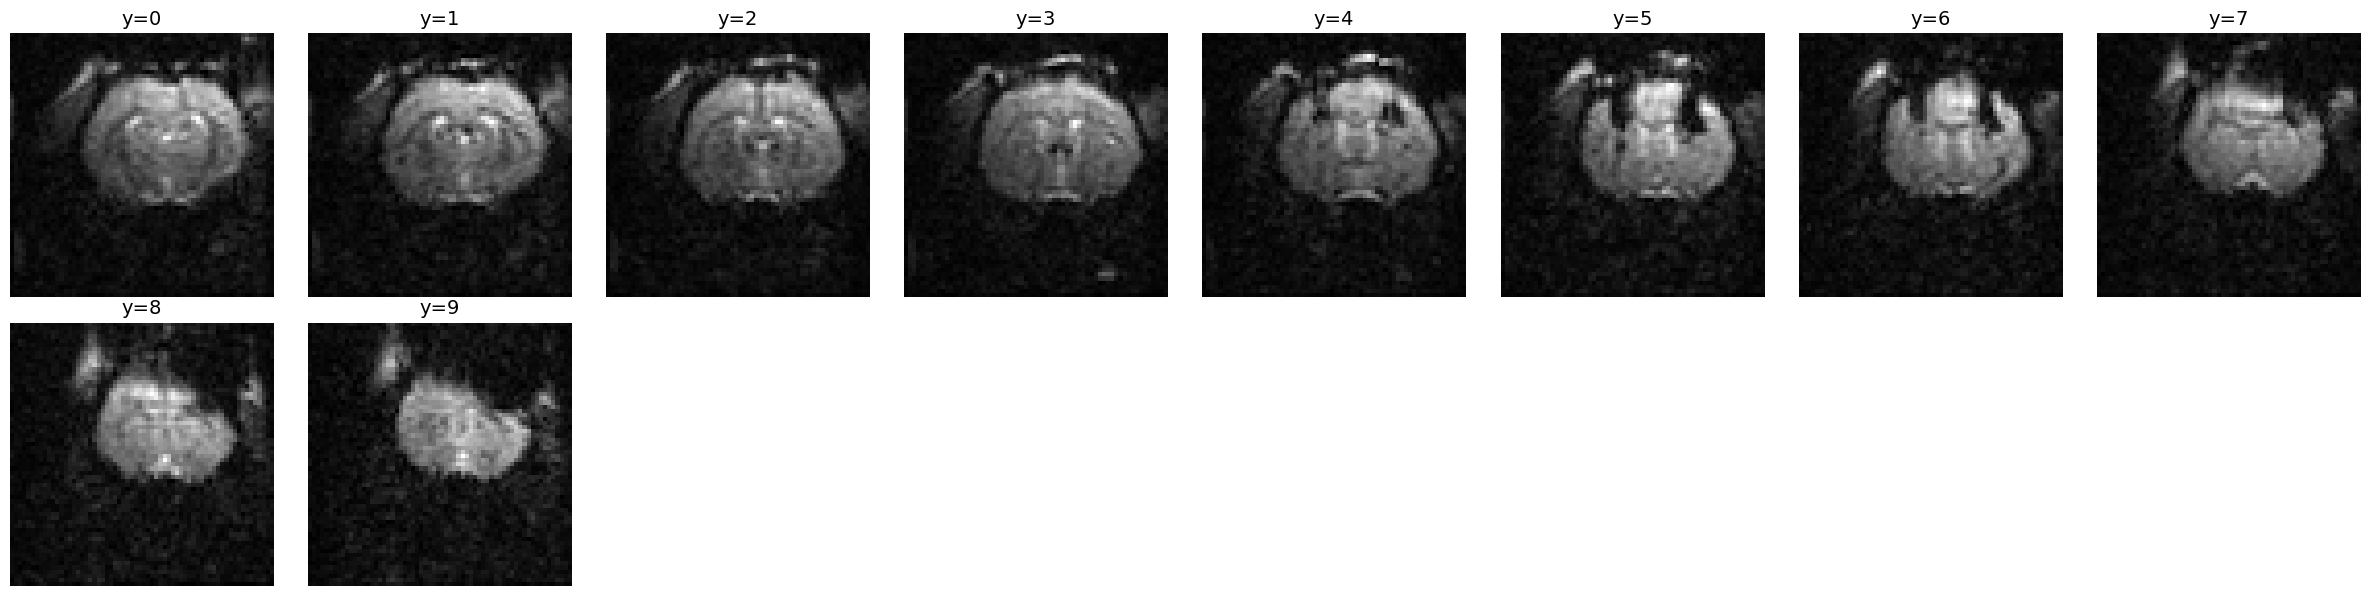

[INFO] Creating motion plots…


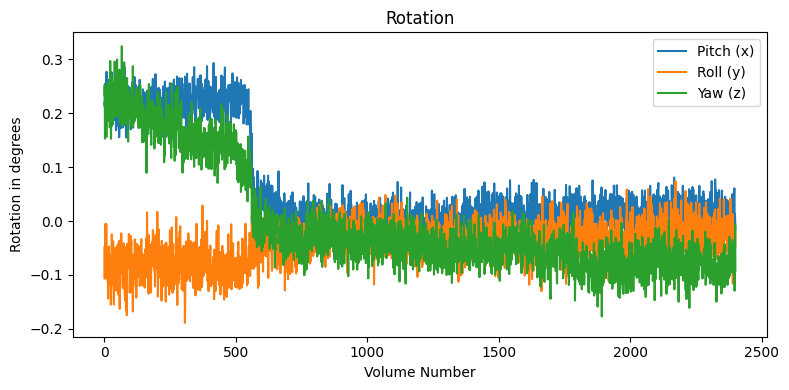

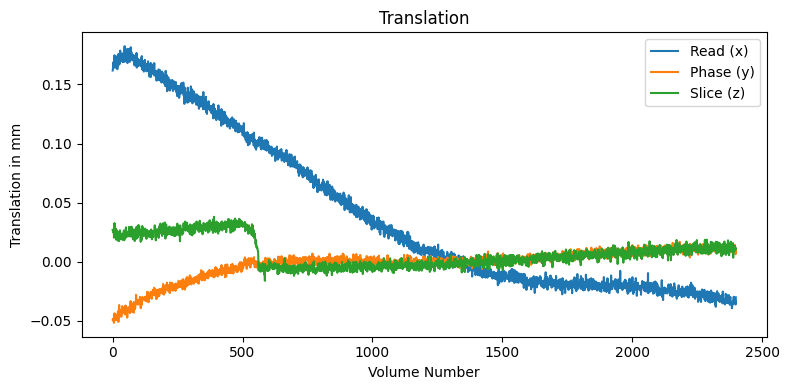

In [68]:
if is_step_enabled("motion_correction"):
    print_header("Applying Motion Correction on raw functional data and plotting motion parameters", bcolors.HEADER)

    if os.path.exists("mc_func.nii.gz"):
        print(f"{bcolors.OKGREEN}Motion Corrected functional data exists. Skipping motion correction (delete mc_func.nii.gz to re-run).{bcolors.ENDC}")
    else:
        motion_correction("middle_vol.nii.gz", f"{input_name_for_next_step}.nii.gz", output_prefix=f"mc_{input_name_for_next_step}",
                          weight_mask=os.path.join(analysed_func_dir, "mask_mean_mc_func.nii.gz"))
    
        
    #Display of the motion corrected image and motion corrected graphs
    if not input_name_for_next_step.startswith("mc_"):
        input_name_for_next_step = f"mc_{input_name_for_next_step}"
    view_images("mc_func.nii.gz", cmap="gray")
    plot_motion_parameters("motion.1D")    
else:
    print_statement("⏭️ Motion Correction not executed", bcolors.NOTIFICATION)


# Move into further subdirectory within Analysed Data Folder

In [69]:
print_statement(f"Analysed Data Path Final: {analysis_dir}", bcolors.NOTIFICATION)
analysis_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysis_dir)

mask_file = os.path.join(analysed_func_dir, "mask_mean_mc_func.nii.gz")
mask_file_cannulas = os.path.join(analysed_func_dir, "mask_mean_mc_func_cannulas.nii.gz")

shutil.copyfile(f"../{input_name_for_next_step}.nii.gz", f"{input_name_for_next_step}.nii.gz")

Analysed Data Path Final: /Volumes/pschmidt/fmri_analysis/AnalysedData/FAP/RGRO_269002_0224_RN_SD_459/27functionalEPI/2026_10_08_184834_pschmidt


'mc_func.nii.gz'

# Selecting Start indices for both: Baseline and Signal

In [70]:
# Opening fsleyes to view the temporally smoothed motion corrected functional data
print_statement("Choose your baseline and signal volumes from the temporally smoothed motion corrected functional data.", bcolors.NOTIFICATION)
subprocess.run(["fsleyes", f"{input_name_for_next_step}.nii.gz"])

# ---------- Common styling ----------
input_layout = widgets.Layout(width="280px", flex="0 0 auto")
label_style = {'description_width': '410px'}

# ---------- Widgets ----------
base_start_idx = widgets.IntText(value=300, description="Baseline Start Index:", layout=input_layout, style=label_style)
sig_start_idx = widgets.IntText(value=1800, description="Signal Start Index:", layout=input_layout, style=label_style)

for w in [base_start_idx, sig_start_idx]:
    w.style.description_width = "180px"

# ---------- Container ----------
row = widgets.HBox([base_start_idx, sig_start_idx],
    layout=widgets.Layout(width="40%", justify_content="space-between", align_items="center", padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e"))

display(row)

Choose your baseline and signal volumes from the temporally smoothed motion corrected functional data.


In [71]:
base_start = int(base_start_idx.value)
sig_start  = int(sig_start_idx.value)
base_end   = base_start + int(win_entered.value)
sig_end   = sig_start + int(win_entered.value)

print_statement(f"Your baseline window selected is: {base_start}_to_{base_end}", bcolors.OKGREEN)
print_statement(f"Your signal window selected is: {sig_start}_to_{sig_end}", bcolors.OKGREEN)

Your baseline window selected is: 300_to_500
Your signal window selected is: 1800_to_2000


# Apply Spatial Smoothing and Generating Signal Change Map

In [72]:
input_name_for_next_step = "mc_func"

In [73]:

motion_corrected_file = "mc_func.nii.gz"

print(f"{input_name_for_next_step}.nii.gz")

if is_step_enabled("spatial_smoothing"):
    print_header("Applying Spatial Smoothing on motion corrected functional data", bcolors.HEADER)
    if input_name_for_next_step.startswith("sm_"):
        # Re-running this cell: the input is already the smoothed file, so never smooth it a second time
        print_statement(f"{input_name_for_next_step}.nii.gz is already smoothed - skipping smoothing. Run the cell above that sets input_name_for_next_step to smooth again.", bcolors.NOTIFICATION)
    else:
        if os.path.exists(mask_file):
            masked_spatial_smoothing(f"{input_name_for_next_step}.nii.gz", mask_file, f"sm_{input_name_for_next_step}.nii.gz", 0.297)
        else:
            print_statement(f"Brain mask {mask_file} not found - smoothing without mask", bcolors.NOTIFICATION)
            spatial_smoothing(f"{input_name_for_next_step}.nii.gz", f"sm_{input_name_for_next_step}.nii.gz", 0.297)
        input_name_for_next_step = f"sm_{input_name_for_next_step}"
else: 
    print_statement("⏭️ Spatial Smoothing not executed, will not get smoothed data in further pipeline", bcolors.NOTIFICATION)
    
compute_mean_range(input_file=f"{input_name_for_next_step}.nii.gz", prefix=f"mean_baseline_image_{base_start}_to_{base_end}.nii.gz", start_idx=base_start, end_idx=base_end)
compute_mean_range(input_file=f"{input_name_for_next_step}.nii.gz", prefix=f"mean_signal_image_{sig_start}_to_{sig_end}.nii.gz", start_idx=sig_start, end_idx=sig_end)

signal_change_map(f"mean_signal_image_{sig_start}_to_{sig_end}.nii.gz", f"mean_baseline_image_{base_start}_to_{base_end}.nii.gz", f"scm_from_sm_{input_name_for_next_step}.nii.gz") # Creating SCM image
signal_change_map(f"{input_name_for_next_step}.nii.gz", f"mean_baseline_image_{base_start}_to_{base_end}.nii.gz", f"scm_timeseries_from_sm_{input_name_for_next_step}.nii.gz") # Creating Signal Change Time Series


compute_mean_range(motion_corrected_file, "mean_mc_func.nii.gz", 200, 500)
masking_file("mean_mc_func.nii.gz", mask_file_shrunk, "cleaned_shrunk_mean_mc_func.nii.gz")
masking_file("mean_mc_func.nii.gz", mask_file, "cleaned_mean_mc_func.nii.gz")

# Exclusion mask for unreliable voxels (brain edge, low baseline, low tSNR); the limits are relative to this animal's own medians
compute_tsnr(f"{input_name_for_next_step}.nii.gz", f"tsnr_baseline_{base_start}_to_{base_end}.nii.gz", base_start, base_end)
create_exclusion_mask(f"mean_baseline_image_{base_start}_to_{base_end}.nii.gz", f"tsnr_baseline_{base_start}_to_{base_end}.nii.gz",
                      candidate_mask=mask_file_shrunk, brain_mask=mask_file, output_mask="mask_thresholded.nii.gz",
                      edge_trim_vox=3, min_baseline_rel=0.5, min_tsnr_rel=0.6)
final_mask_used = os.path.join(analysis_dir, "mask_thresholded.nii.gz")


if is_step_enabled("masking_file"):
    print_header("Applying Mask on motion corrected functional data", bcolors.HEADER)
    masking_file(f"scm_from_sm_{input_name_for_next_step}.nii.gz", final_mask_used, f"clean_thresh_scm_from_sm_{input_name_for_next_step}.nii.gz")
    masking_file(f"scm_from_sm_{input_name_for_next_step}.nii.gz", mask_file_shrunk, f"clean_shrunk_scm_from_sm_{input_name_for_next_step}.nii.gz")
    masking_file(f"scm_from_sm_{input_name_for_next_step}.nii.gz", mask_file, f"cleaned_scm_from_sm_{input_name_for_next_step}.nii.gz")

else:
    print_statement("⏭️ Masking not executed, will not get cleaned data in further pipeline", bcolors.NOTIFICATION)


input_file_for_coreg = analysis_dir / "cleaned_mean_mc_func.nii.gz"
scm_for_coreg = analysis_dir / f"cleaned_scm_from_sm_{input_name_for_next_step}.nii.gz"

mc_func.nii.gz

**************************************************************************************************************************************
                                    Applying Spatial Smoothing on motion corrected functional data                                    
**************************************************************************************************************************************

Masked smoothing completed successfully.
[INFO] Running: 3dTstat -mean -prefix mean_baseline_image_300_to_500.nii.gz sm_mc_func.nii.gz[300..500]


++ 3dTstat: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: KR Hammett & RW Cox
++ Output dataset ./mean_baseline_image_300_to_500.nii.gz
++ 3dTstat: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: KR Hammett & RW Cox


[OK] Mean baseline image saved.
[INFO] Running: 3dTstat -mean -prefix mean_signal_image_1800_to_2000.nii.gz sm_mc_func.nii.gz[1800..2000]


++ Output dataset ./mean_signal_image_1800_to_2000.nii.gz


[OK] Mean baseline image saved.
[OK] Percent Signal Change Map saved → scm_from_sm_sm_mc_func.nii.gz
[OK] Percent Signal Change Map saved → scm_timeseries_from_sm_sm_mc_func.nii.gz
[INFO] Running: 3dTstat -mean -prefix mean_mc_func.nii.gz mc_func.nii.gz[200..500]


++ 3dTstat: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: KR Hammett & RW Cox
++ Output dataset ./mean_mc_func.nii.gz


[OK] Mean baseline image saved.
[OK] Masked file saved → cleaned_shrunk_mean_mc_func.nii.gz
[OK] Masked file saved → cleaned_mean_mc_func.nii.gz
[OK] tSNR map saved -> tsnr_baseline_300_to_500.nii.gz
Exclusion mask: 6117 candidate voxels
  removed   423 voxels with edge distance < 3 voxels
  removed     1 voxels with baseline < 0.5 x median (40954)
  removed   147 voxels with tSNR < 0.6 x median (39.6)
  added back 9 enclosed hole voxels
Exclusion mask saved: mask_thresholded.nii.gz (5555 voxels kept)

**************************************************************************************************************************************
                                          Applying Mask on motion corrected functional data                                           
**************************************************************************************************************************************

[OK] Masked file saved → clean_thresh_scm_from_sm_sm_mc_func.nii.gz
[OK] Masked file s

# Converting Structural Data into NIFTI and Processing it

Analysed Data Path: /Volumes/pschmidt/fmri_analysis/AnalysedData/FAP/RGRO_269002_0224_RN_SD_459/18anatomy

**************************************************************************************************************************************
                                             Converting Bruker to NIFTI: Structural Data                                              
**************************************************************************************************************************************

NIfTI file already exists. Skipping conversion.
Cleaning the structural image by manually creating mask
Structural Image for Coregistration exists.


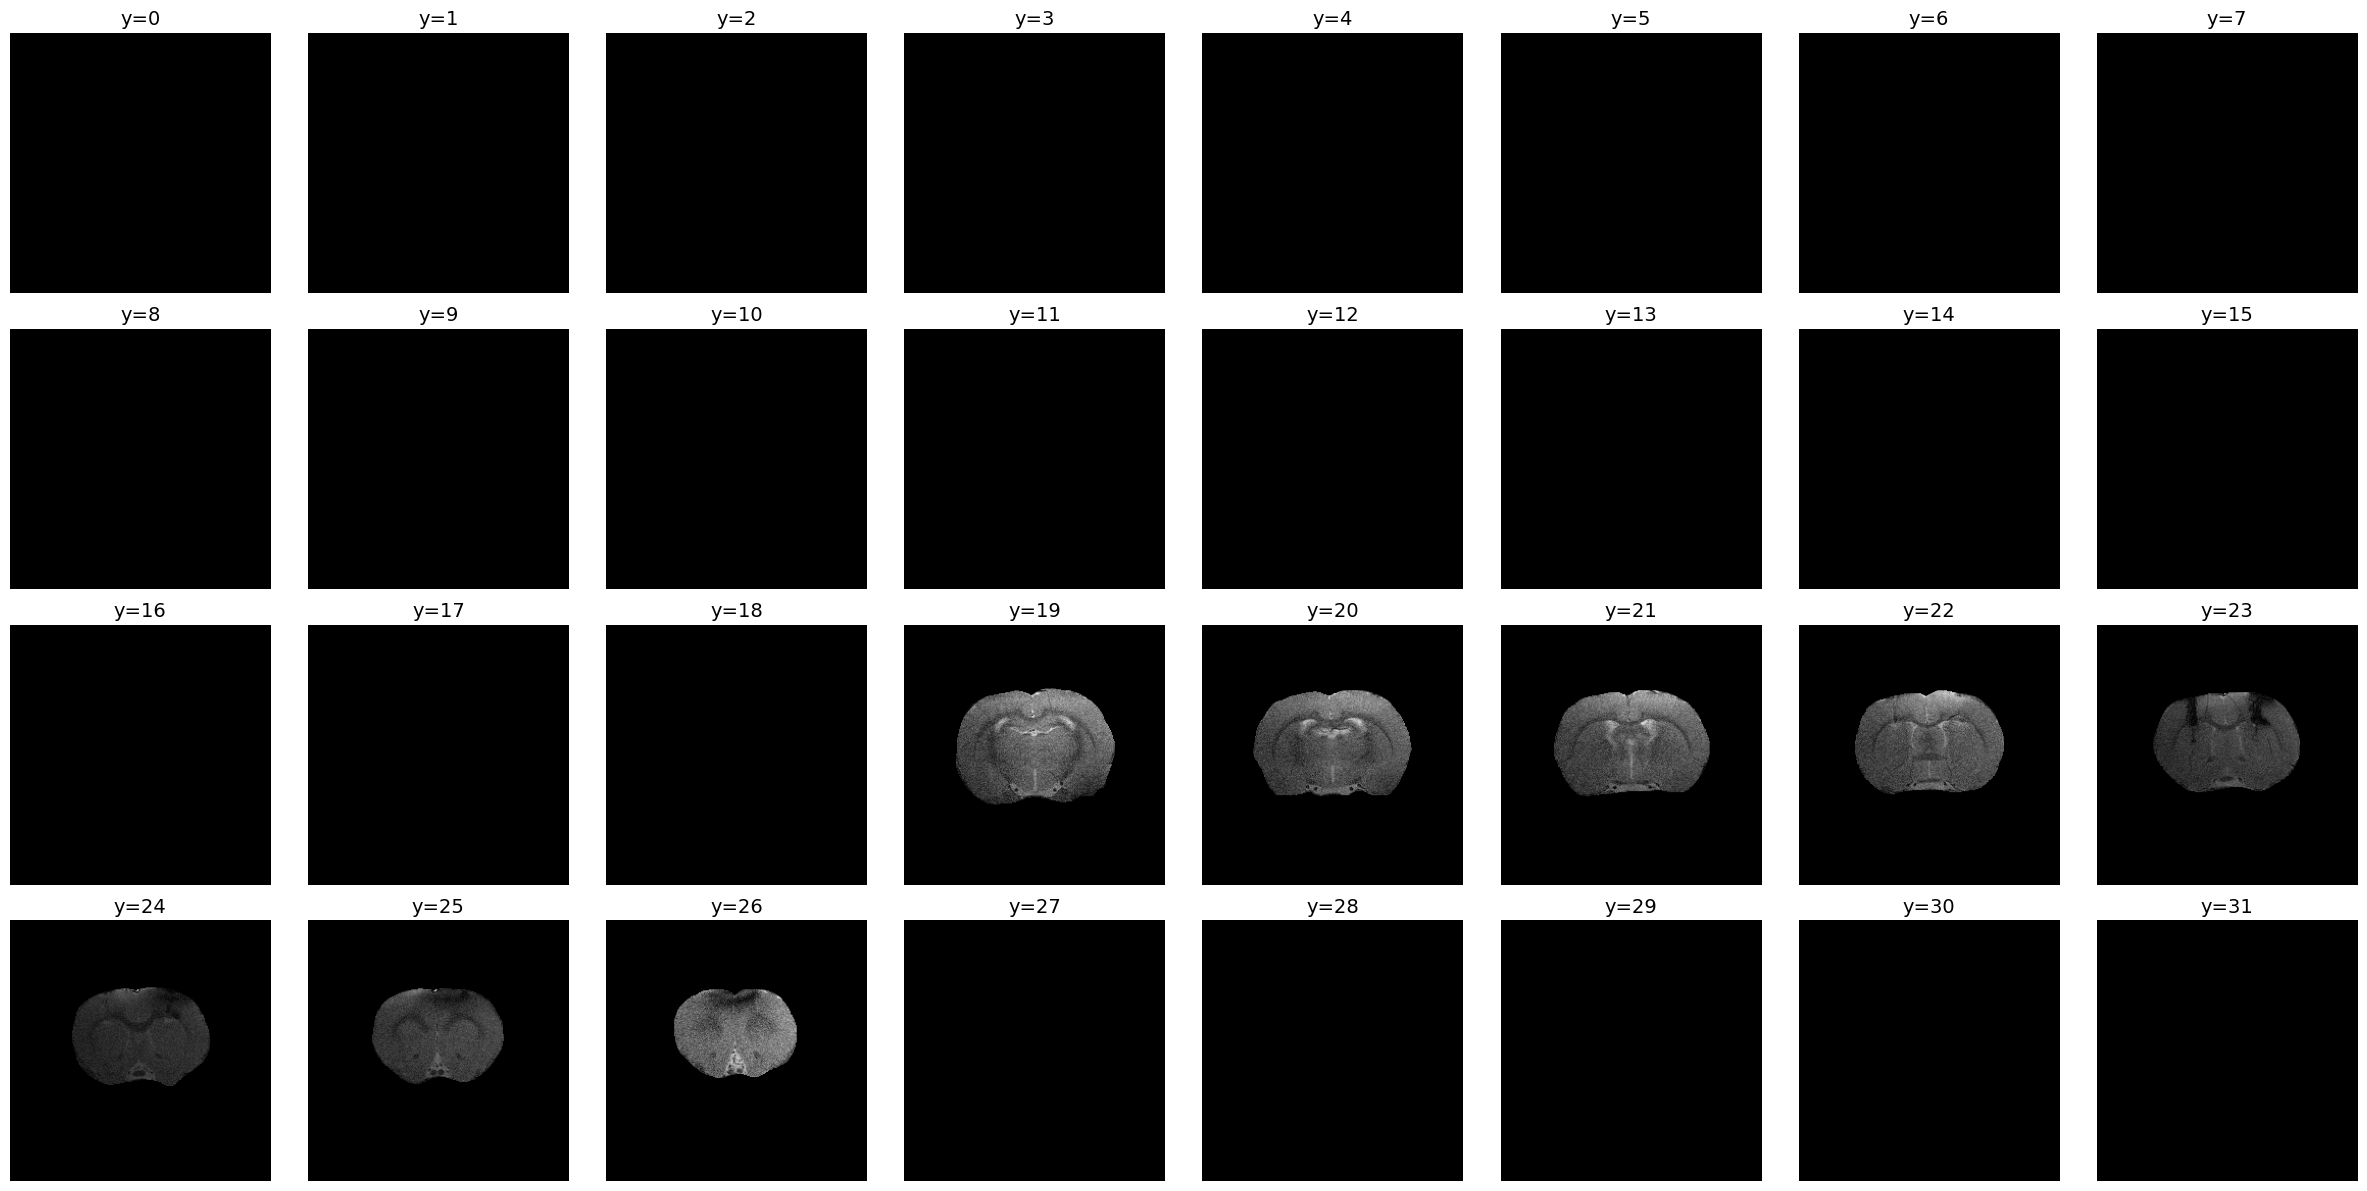

In [74]:
print_statement(f"Analysed Data Path: {analysed_struct_dir}", bcolors.NOTIFICATION)
analysed_struct_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysed_struct_dir)

if is_step_enabled("bruker_to_nifti"):
    print_header("Converting Bruker to NIFTI: Structural Data", bcolors.HEADER)

    nifti_file = analysed_struct_dir / "struct.nii.gz"
    if nifti_file.exists():
        print_statement("NIfTI file already exists. Skipping conversion.", bcolors.OKGREEN)
    else:
        bruker_to_nifti(in_path, struct_scan_number, "struct.nii.gz")

else:
    print_statement("⏭️ Data Conversion Step not executed, May cause trouble in running further analysis", bcolors.NOTIFICATION)


#Cleaning the structural image by masking it with a manually created mask

if is_step_enabled("masking_file"):
    print_statement("Cleaning the structural image by manually creating mask", bcolors.NOTIFICATION)
    
    if os.path.exists("cleaned_struct.nii.gz"):
        print_statement("Structural Image for Coregistration exists.", bcolors.OKGREEN)
    else:
        print_statement("Please create a mask for the structural image and save it as mask_struct.nii.gz", bcolors.NOTIFICATION)
        subprocess.run(["fsleyes", "struct.nii.gz", os.path.join(analysed_func_dir, "middle_vol.nii.gz")])
        masking_file("struct.nii.gz", "mask_struct.nii.gz", "cleaned_struct.nii.gz")

    structural_file_for_coregistration = os.path.join(analysed_struct_dir, "cleaned_struct.nii.gz")    
    view_images("cleaned_struct.nii.gz", cmap="gray")
    
    #Further shrinking the mask for structural image to get better coregistration results as structural image has high spatial resolution than functional image
    

else:
    print_statement("⏭️ Masks not generated, will not get cleaned data in further pipeline", bcolors.NOTIFICATION)    
    structural_file_for_coregistration = os.path.join(analysed_struct_dir, "struct.nii.gz")    
    view_images("struct.nii.gz", cmap="gray")



Analysed Data Path Final: /Volumes/pschmidt/fmri_analysis/AnalysedData/FAP/RGRO_269002_0224_RN_SD_459/27functionalEPI/2026_10_08_184834_pschmidt
Phase-encoding axis: voxel axis 'z' of func.nii.gz (from brkraw BIDS sidecar)
Scaling along the phase-encoding axis (z of the AFNI coordinate system) is allowed between 0.92 and 1.08
261008-19:26:42,413 nipype.interface INFO:
	 stderr 2026-10-08T19:26:42.413221:++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
261008-19:26:42,414 nipype.interface INFO:
	 stderr 2026-10-08T19:26:42.413221:++ Authored by: Zhark the Registrator
261008-19:26:42,432 nipype.interface INFO:
	 stderr 2026-10-08T19:26:42.432861:++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/FAP/RGRO_269002_0224_RN_SD_459/27functionalEPI/2026_10_08_184834_pschmidt/cleaned_mean_mc_func.nii.gz
261008-19:26:42,433 nipype.interface INFO:
	 stderr 2026-10-08T19:26:42.432861:++ Base dataset:   /Volumes/pschmidt/fmri_analysis/AnalysedData/FAP/RGRO_269002_0224_RN

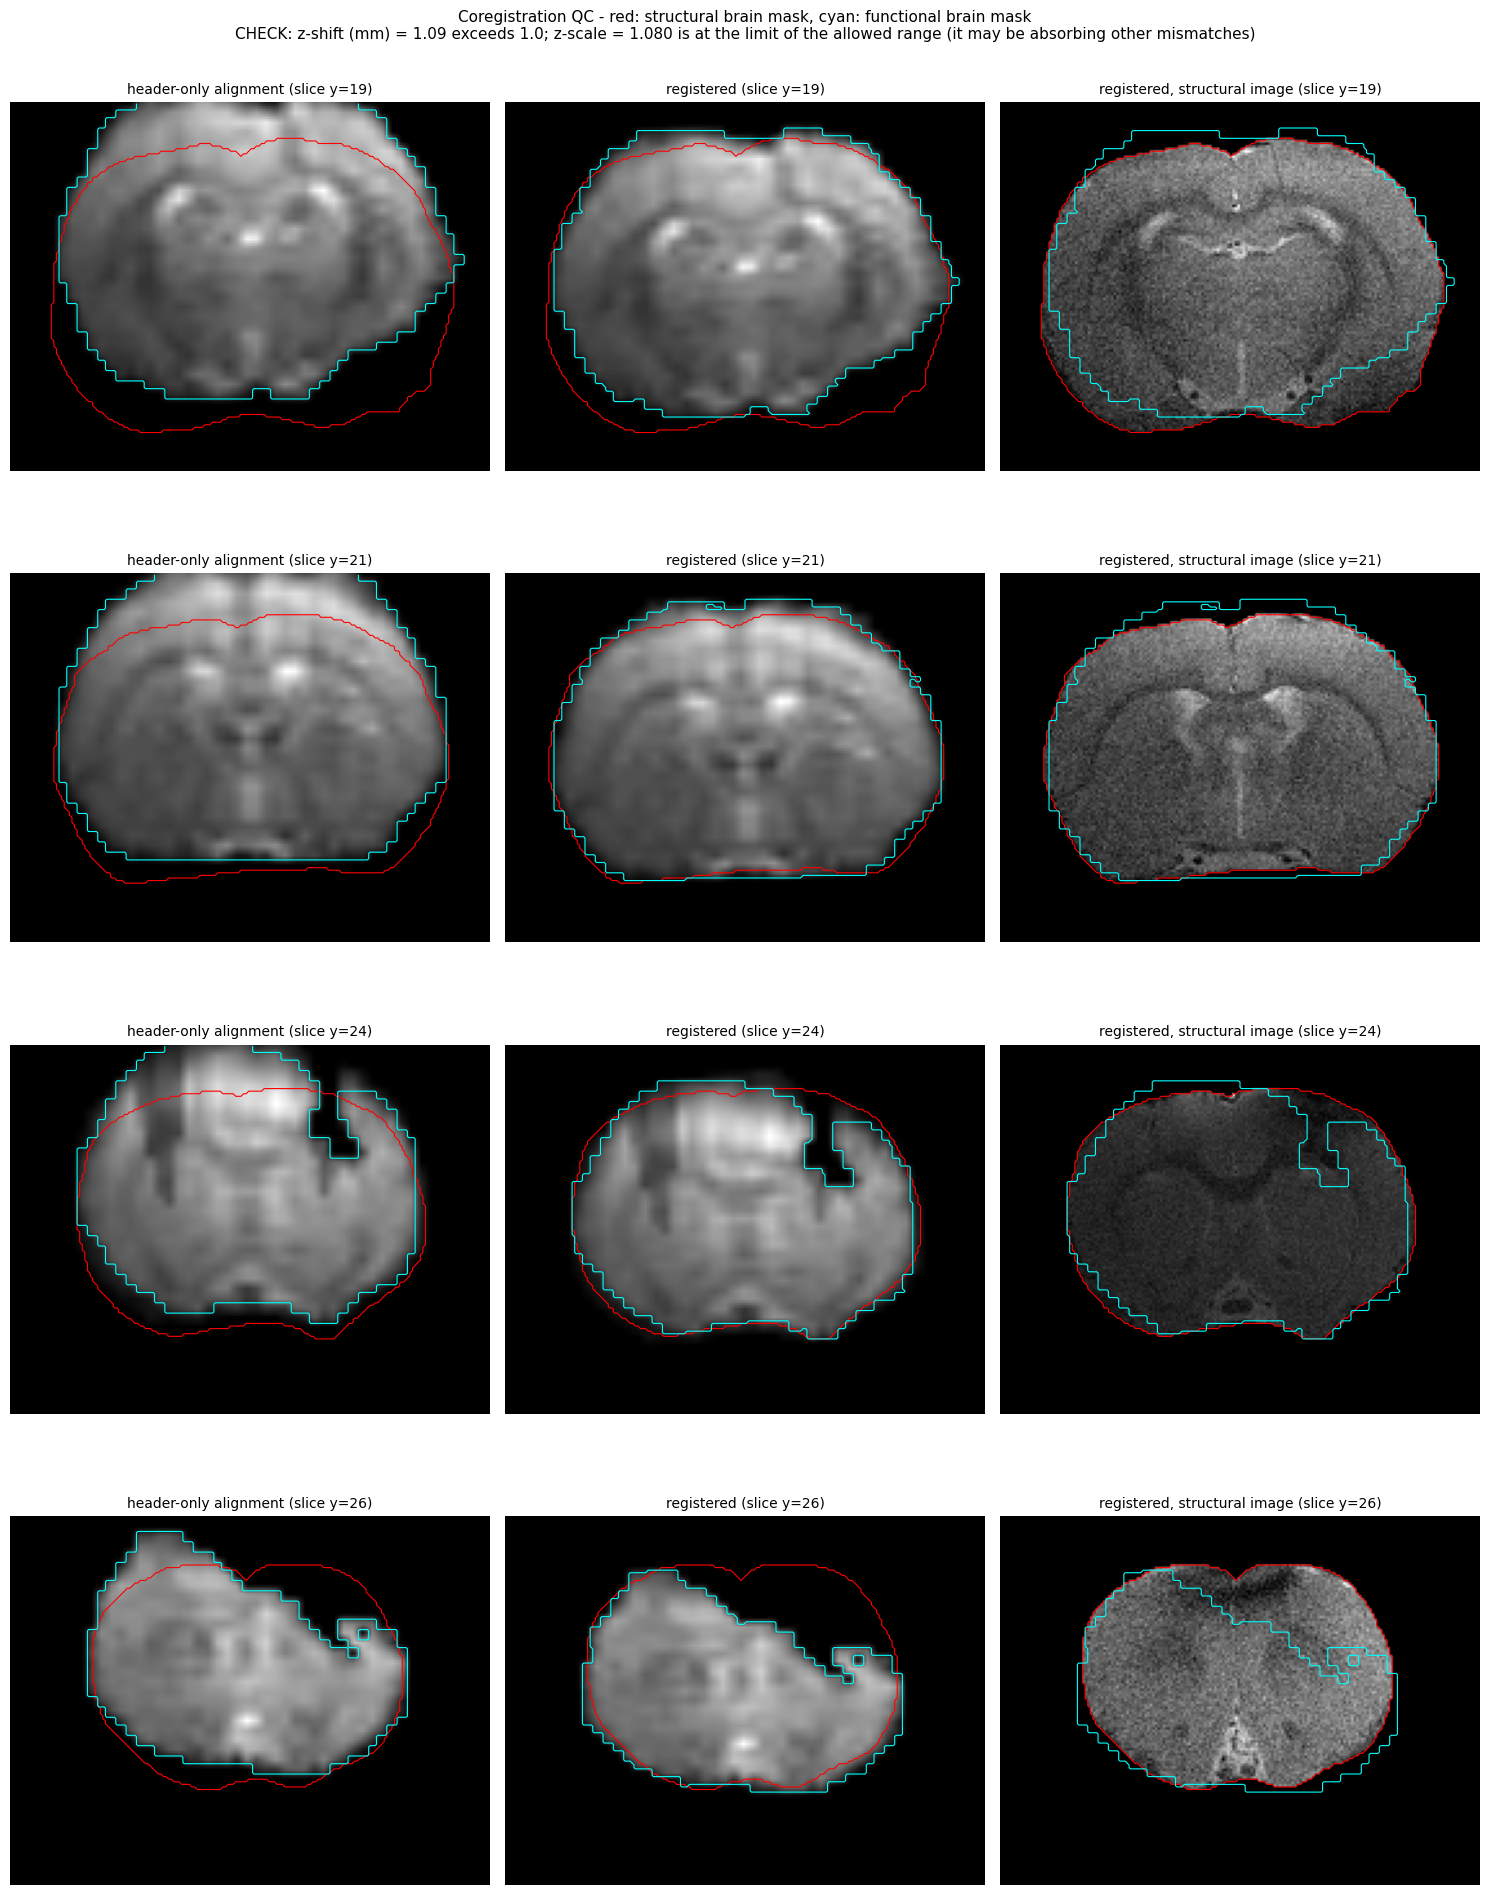

Estimated transform:
  x-shift (mm)      0.023
  y-shift (mm)     -0.035
  z-shift (mm)      1.094  <-- large
  z-angle (deg)    -0.054
  x-angle (deg)    -0.146
  y-angle (deg)     1.262
  z-scale           1.080  <-- at the limit of the allowed range

NMI with structural image (higher is better): registered 1.0400, header-only 1.0331
Brain mask Dice (in functional coverage): registered 0.914, header-only 0.848
Mean in-plane edge distance (mm):         registered 0.602, header-only 0.906
Brain width functional / structural (x, z): registered 1.006, 1.054 | header-only 1.004, 1.135
Overlay image: coregistration_qc.png

RESULT: CHECK THE COREGISTRATION - z-shift (mm) = 1.09 exceeds 1.0; z-scale = 1.080 is at the limit of the allowed range (it may be absorbing other mismatches)
[WARNING] z-shift (mm) = 1.09 exceeds 1.0
[WARNING] z-scale = 1.080 is at the limit of the allowed range (it may be absorbing other mismatches)


++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/FAP/RGRO_269002_0224_RN_SD_459/27functionalEPI/2026_10_08_184834_pschmidt/mask_thresholded.nii.gz
++ Base dataset:   (not given)
++ Loading datasets into memory
 +        -cmass x y z shifts =    0.000    0.000    0.000
 +  shift search range is +/- =    7.584    1.445    7.584
++ OpenMP thread count = 11
++ ========== Applying transformation to 1 sub-bricks ==========
++ Output dataset ./struct_mask_from_functional.nii.gz
++ 3dAllineate: total CPU time = 0.1 sec  Elapsed = 0.3
++ ###########################################################


[OK] Mask transformed to structural space -> struct_mask_from_functional.nii.gz
Structural brain restriction: 57116 -> 56841 voxels (struct_mask_final.nii.gz)
[OK] Masked file saved → cleaned_signal_change_map_coregistered_structural_space.nii.gz


'cleaned_signal_change_map_coregistered_structural_space.nii.gz'

In [80]:

print_statement(f"Analysed Data Path Final: {analysis_dir}", bcolors.NOTIFICATION)
analysis_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysis_dir)

def coregistration_afni(
    input_file1=None,
    input_file2=None,
    reference_file=None,
    output_file1=None,
    output_file2=None,
    estimate_affine=True,
    apply_affine=True,
    affine_mat="mean_func_struct_aligned.aff12.1D",
    pe_scale_axis=None,
    pe_scale_range=(0.92, 1.08),
    max_rot_deg=5.0,
    max_shift_mm=2.0,
):
    """
    Rigid-body coregistration of the functional mean image to the structural image (AFNI 3dAllineate), and
    application of the transform to a second image (the signal change map).

    Parameters
    ----------
    input_file1 : str
        Image used to estimate the transform (cleaned mean functional image).
    input_file2 : str
        Image the estimated transform is applied to (signal change map).
    reference_file : str
        Structural image defining the target space.
    output_file1, output_file2 : str
        Outputs of the estimation step and of the apply step.
    estimate_affine, apply_affine : bool
        Run the estimation / the apply step.
    affine_mat : str
        Transform matrix file (written by the estimation, read by the apply step).
    pe_scale_axis : "x", "y", "z" or None
        If given, the registration may also scale the functional image along this axis (the phase-encoding
        axis, where EPI is stretched or compressed by field distortion). All other scales are fixed at 1 and
        all shears at 0. None = rigid body only (use this when distortion correction was applied).
    pe_scale_range : (float, float)
        Allowed range of that scale (1 = unchanged).
    max_rot_deg, max_shift_mm : float
        Largest rotation and shift the registration may use.
    """
    if pe_scale_axis not in (None, "x", "y", "z"):
        raise ValueError("pe_scale_axis must be None, 'x', 'y' or 'z'")

    results = {}

    if reference_file is None:
        raise ValueError("reference_file must be provided")

    # -------- STEP 1: Estimate transform --------
    if estimate_affine:
        if output_file1 is None:
            raise ValueError("output_file1 must be provided when estimate_affine=True")
        if input_file1 is None:
            raise ValueError("input_file1 must be provided when estimate_affine=True")

        coreg_wo_affine = afni.Allineate()
        coreg_wo_affine.inputs.in_file = input_file1
        coreg_wo_affine.inputs.reference = reference_file

        # Rigid body, optionally plus a scale along the phase-encoding axis; everything is bounded
        limits = f"-maxrot {max_rot_deg} -maxshf {max_shift_mm}"
        if pe_scale_axis is None:
            coreg_wo_affine.inputs.warp_type = "shift_rotate"
        else:
            # affine_general parameters: 1-3 shifts, 4-6 angles, 7-9 scales (x, y, z), 10-12 shears
            scale_param = {"x": 7, "y": 8, "z": 9}[pe_scale_axis]
            fixed = [(p, 1) for p in (7, 8, 9) if p != scale_param] + [(10, 0), (11, 0), (12, 0)]
            limits += f" -parang {scale_param} {pe_scale_range[0]} {pe_scale_range[1]}"
            limits += "".join(f" -parfix {p} {v}" for p, v in fixed)
            coreg_wo_affine.inputs.warp_type = "affine_general"
        coreg_wo_affine.inputs.args = limits

        # For EPI <-> anat, AFNI generally recommends lpc/lpc+ style costs
        # more than generic affine-style costs
        coreg_wo_affine.inputs.cost = "nmi"

        coreg_wo_affine.inputs.two_pass = True
        coreg_wo_affine.inputs.verbose = True
        coreg_wo_affine.inputs.out_matrix = affine_mat
        coreg_wo_affine.inputs.out_param_file = "params.1D"
        coreg_wo_affine.inputs.out_file = output_file1

        coreg_wo_affine.run()

        print(f"[OK] Rigid transform estimated and saved → {affine_mat}")
        print(f"[OK] Coregistered image (step 1) → {output_file1}")

        results["step1"] = output_file1

    # -------- STEP 2: Apply transform --------
    if apply_affine:
        if output_file2 is None:
            raise ValueError("output_file2 must be provided when apply_affine=True")
        if input_file2 is None:
            raise ValueError("input_file2 must be provided when apply_affine=True")

        coreg_with_affine = afni.Allineate()
        coreg_with_affine.inputs.in_file = input_file2
        coreg_with_affine.inputs.reference = reference_file
        coreg_with_affine.inputs.in_matrix = affine_mat
        coreg_with_affine.inputs.master = reference_file
        coreg_with_affine.inputs.final_interpolation = "linear"
        coreg_with_affine.inputs.verbose = True
        coreg_with_affine.inputs.out_file = output_file2

        coreg_with_affine.run()

        print(f"[OK] Transform applied → {output_file2}")
        results["step2"] = output_file2

    return results

# Scaling along the phase-encoding axis is only allowed without distortion correction (otherwise the distortion is already corrected voxel by voxel)
pe_scale_range = (0.92, 1.08)
if distortion_enabled:
    pe_scale_axis = None
    print_statement("Distortion correction was applied: coregistration without phase-encoding scaling", bcolors.NOTIFICATION)
else:
    pe_scale_axis = get_phase_encoding_axis(analysed_func_dir / "func.nii.gz", in_path, func_scan_number, manual_axis=pe_axis)
    if pe_scale_axis is None:
        print_statement("Phase-encoding axis unknown: coregistration without scaling. Choose the axis in the 'Phase-encoding axis' dropdown (not 'auto') to allow it.", bcolors.NOTIFICATION)
    else:
        print_statement(f"Scaling along the phase-encoding axis ({pe_scale_axis} of the AFNI coordinate system) is allowed between {pe_scale_range[0]} and {pe_scale_range[1]}", bcolors.NOTIFICATION)

coregistration_afni(input_file_for_coreg, scm_for_coreg, structural_file_for_coregistration, output_file1="mean_func_struct_aligned.nii.gz", output_file2="signal_change_map_coregistered_structural_space.nii.gz", estimate_affine=True, apply_affine=True, affine_mat="mean_func_struct_aligned.aff12.1D",
                    pe_scale_axis=pe_scale_axis, pe_scale_range=pe_scale_range) # Estimating affnine and applying it to SCM


# Quality check of the coregistration (warnings, overlay image coregistration_qc.png, report coregistration_qc.txt); changes nothing
coregistration_qc(str(input_file_for_coreg), structural_file_for_coregistration, "mean_func_struct_aligned.aff12.1D", params_file="params.1D",
                  source_mask=mask_file, struct_mask=os.path.join(analysed_struct_dir, "mask_struct.nii.gz"),
                  max_scale_dev=max(1 - pe_scale_range[0], pe_scale_range[1] - 1))

# The exclusion mask is defined in functional space (where the signal change is computed) and moved with the same affine
transform_mask_to_structural(final_mask_used, structural_file_for_coregistration, "mean_func_struct_aligned.aff12.1D", "struct_mask_from_functional.nii.gz")
restrict_to_structural_brain("struct_mask_from_functional.nii.gz", structural_file_for_coregistration, "struct_mask_final.nii.gz", erode_vox=2)
masking_file("signal_change_map_coregistered_structural_space.nii.gz", "struct_mask_final.nii.gz", "cleaned_signal_change_map_coregistered_structural_space.nii.gz")



# ROI Analysis

In [27]:
#Marking ROIs and saving time courses

print_header("Marking ROIs and saving time courses", bcolors.HEADER)

print_statement("Please create ROIs on the functional time series and save them in the following particular format:", bcolors.NOTIFICATION) 
print_statement("roi_{what protein/aav is there}_{is it direct injection or aav}_{analyte injeted}_{hemisphere side}.nii.gz", bcolors.NOTIFICATION)
print_statement("For Example: if GCaMP6f is directly injected in the left hemisphere and dopamine is injected in the right hemisphere following a viral injection, then the following ROIs should be created:", bcolors.NOTIFICATION) 
print_statement("roi_GCaMP6f_direct_left.nii.gz or roi_dopamine_aav_right.nii.gz", bcolors.FAIL)  

subprocess.run(["fsleyes", f"{input_name_for_next_step}.nii.gz"])

files_list_roi = os.listdir(analysis_dir)


for file in files_list_roi:
    if file.startswith("roi_") and file.endswith("left.nii.gz"):
        roi_left = file
        mean_signal_left = roi_analysis(f"{input_name_for_next_step}.nii.gz", roi_left, n_vols, tr, base_start, base_end, sig_start, sig_end, inj_start=600, inj_end=1200)
    if file.startswith("roi_") and file.endswith("right.nii.gz"):
        roi_right = file
        mean_signal_right = roi_analysis(f"{input_name_for_next_step}.nii.gz", roi_right, n_vols, tr, base_start, base_end, sig_start, sig_end, inj_start=600, inj_end=1200)



**************************************************************************************************************************************
                                                 Marking ROIs and saving time courses                                                 
**************************************************************************************************************************************

Please create ROIs on the functional time series and save them in the following particular format:
roi_{what protein/aav is there}_{is it direct injection or aav}_{analyte injeted}_{hemisphere side}.nii.gz
For Example: if GCaMP6f is directly injected in the left hemisphere and dopamine is injected in the right hemisphere following a viral injection, then the following ROIs should be created:
roi_GCaMP6f_direct_left.nii.gz or roi_dopamine_aav_right.nii.gz
